# Classical Static Graph Metrics: Stage-Mean EEG Connectivity Networks

## Purpose

This notebook is the first classical network-analysis stage of the project. It
takes the processed epoch-level weighted phase-lag index (wPLI) connectivity
graphs created during preprocessing and converts them into one representative
functional-connectivity network per participant, sleep stage, and frequency
band.

The aim is to describe how the static topology of EEG functional-connectivity
networks differs across sleep stages and frequency bands. The analysis uses
stage-mean wPLI graphs: for each participant, all valid 30-second epochs
belonging to the same sleep stage and frequency band are averaged elementwise
to create one weighted graph.

```text
Processed subject-level HDF5 files
(one wPLI graph per 30-second epoch and band)
        ↓
Group each subject's epochs by sleep stage
        ↓
Elementwise average wPLI matrices within each subject × stage × band
        ↓
One stage-mean weighted graph per subject × stage × band
        ↓
Calculate static weighted graph metrics
        ↓
Inspect subject-level patterns and prepare a table for later statistics
```

This notebook is primarily descriptive and methodological. It creates the
stage-mean graph dataset, calculates static network metrics, visualizes
participant-level patterns, and prepares an analysis table for later
subject-aware statistical inference.

It does not yet establish final population-level sleep-stage effects. Visual
patterns and metric differences should be treated as exploratory until they are
evaluated with appropriate within-subject/group-level statistical analyses.

---

## Input data

The input files are the processed subject-level HDF5 files produced by the EEG
preprocessing and connectivity pipeline:

```text
graphs_output/
├── EPCTL01.h5
├── EPCTL02.h5
├── ...
└── EPCTL29.h5
```

Each input file contains one wPLI connectivity matrix per retained 30-second
epoch and frequency band, together with:

- sleep-stage labels
- original epoch indices
- 83 EEG channel names
- the number of interpolated channels in each retained epoch
- wPLI arrays for delta, theta, alpha, sigma, and beta bands

The present notebook uses the following sleep stages:

```text
Wake
N1
N2
N3
REM
```

The frequency bands are:

| Band | Frequency range |
|---|---:|
| Delta | 0.5–4 Hz |
| Theta | 4–8 Hz |
| Alpha | 8–12 Hz |
| Sigma | 12–16 Hz |
| Beta | 16–30 Hz |

---

## Stage-mean graph construction

For each participant, frequency band, and sleep stage, the notebook selects all
valid retained epochs with that stage label and averages their wPLI adjacency
matrices element by element.

In code-like notation:

```text
stage_mean_graph[subject, band, stage]
    = average of all epoch-level wPLI matrices
      from that subject, band, and stage
```

This produces one 83 × 83 weighted, undirected connectivity graph for every
available:

```text
subject × frequency band × sleep stage
```

The number of epochs contributing to every stage-mean graph is stored as
metadata. This is important because different participants can contribute very
different numbers of valid epochs to a given sleep stage.

The stage-mean graphs are saved as separate HDF5 files so that later analyses
can reuse the same well-defined graph inputs without repeating the aggregation
step.

---

## Beta-band sensitivity versions

An earlier quality-control analysis suggested that strong beta-band edges may
be disproportionately associated with peripheral or outer-ring electrodes.
These electrodes can be more vulnerable to residual muscle-related
contamination.

For this reason, the notebook supports two beta-band graph versions:

```text
full
    All positive wPLI edges are retained.

exclude_both_peripheral
    All 83 EEG nodes are retained, but beta-band edges connecting two
    peripheral electrodes are set to zero.
```

The peripheral-edge exclusion is a sensitivity analysis rather than a claim
that all peripheral beta connectivity is artifactual. Its purpose is to check
whether later beta-band findings remain present after reducing a specifically
identified potential source of contamination.

The selected beta-edge mode is stored in the HDF5 output and in the metrics
table. Results from different beta-edge modes should not be mixed in a single
statistical analysis.

---

## Static graph metrics

All metrics are calculated on unthresholded, weighted stage-mean wPLI graphs.

```text
No proportional thresholding is applied.
No absolute wPLI threshold is applied.
All positive wPLI edges are retained.
```

The diagonal is set to zero, and graph symmetry is enforced numerically before
metric calculation.

For shortest-path calculations, connection strength is transformed into a
distance:

```text
edge distance = 1 / wPLI
```

Therefore, stronger wPLI edges correspond to shorter functional-network
distances.

The notebook calculates the following measures:

| Metric | Interpretation |
|---|---|
| `mean_wpli` | Average connectivity strength across all unique channel pairs |
| `mean_node_strength` | Average total weighted connectivity of a node |
| `mean_weighted_clustering` | Local weighted clustering; descriptive proxy for local segregation |
| `weighted_global_efficiency` | Global ease of communication through short weighted paths |
| `weighted_characteristic_path_length` | Average shortest weighted path length; lower values indicate shorter paths |
| `modularity_louvain` | Strength of community structure detected with weighted Louvain partitioning |
| `n_louvain_communities` | Number of Louvain communities found in the graph |
| `n_nodes` | Number of retained graph nodes; expected to be 83 |
| `n_edges` | Number of positive weighted edges |
| `edge_density` | Fraction of possible graph edges that are present |
| `n_connected_components` | Number of disconnected graph components |
| `largest_component_size` | Number of nodes in the largest connected component |
| `minimum_nonzero_wpli` | Smallest retained positive wPLI value; a useful graph-density check |

Louvain community detection uses a fixed random seed to improve reproducibility
across reruns.

Because the networks are dense, fully weighted, and unthresholded, metrics such
as modularity and weighted clustering should be interpreted carefully and
compared consistently across all subjects and stages.

---

## Notebook outputs

This notebook produces three kinds of outputs.

### 1. Stage-mean graph files

One HDF5 file is created per participant:

```text
graphs_output/
└── stage_mean_wpli_graphs_<beta_mode>/
    ├── EPCTL01_stage_means.h5
    ├── EPCTL02_stage_means.h5
    └── ...
```

Each file contains the participant's stage-mean wPLI graphs for all available
frequency bands and sleep stages, together with channel names and the number of
epochs averaged per stage.

### 2. Static-metric table

The notebook creates one row per:

```text
subject × frequency band × sleep stage
```

The resulting table includes all static graph metrics, the selected beta-edge
mode, and the number of epochs used for the corresponding stage-mean graph.

This table is the main numerical output of the notebook and should be saved as
a CSV or Parquet file for later subject-aware statistical analysis.

### 3. Exploratory plots

The notebook includes descriptive visualizations of metric changes across sleep
stages and subjects.

These plots are useful for:

- Checking that metric values are plausible and numerically stable.
- Identifying incomplete stage coverage or outlier participants.
- Inspecting participant-to-participant heterogeneity.
- Comparing each stage with the same participant's Wake value.
- Generating hypotheses for later statistical analysis.
- Checking whether the beta sensitivity version changes apparent patterns.

These figures are exploratory and should not be interpreted as population-level
evidence without subject-aware statistical testing.

---

## Current visualizations

### Wake-referenced subject heatmaps

The notebook displays heatmaps for selected metrics, including:

```text
mean_wpli
mean_weighted_clustering
modularity_louvain
```

For each frequency band, rows represent participants and columns represent
sleep stages. Each heatmap cell shows the change from that same participant's
Wake value:

```text
change from Wake
    = metric value in a given stage
      minus
      metric value in Wake for the same subject and band
```

A diverging colour scale is centred at zero:

```text
positive value: metric increased relative to Wake
negative value: metric decreased relative to Wake
zero: no change relative to Wake
```

**Purpose:** These heatmaps make within-subject patterns and between-subject
heterogeneity visible. They are especially useful for detecting whether an
apparent average trend is broadly consistent or driven by only a few
participants.

**Limitation:** The heatmaps are descriptive. They do not account for missing
stages, unequal numbers of epochs per stage, multiple comparisons, or the
repeated-measures structure required for formal group-level inference.

---

## Interpretation notes

- Every row of the metrics table represents a stage-mean graph from one
  participant, not an independent epoch-level observation.
- The number of epochs used to create a stage-mean graph should be retained and
  considered during later sensitivity analyses.
- A group-level analysis should preserve the within-subject nature of the
  design. Participants must not be treated as independent at every
  stage-by-band row without accounting for repeated measures.
- The same metric calculation and beta-edge mode must be used consistently
  across all graphs within a comparison.
- Comparisons across frequency bands require caution because absolute wPLI
  magnitudes and network properties can differ intrinsically by band.
- The present unthresholded analysis is one defensible representation of the
  data, but later robustness checks may compare results across reasonable graph
  construction choices.
- The visualizations are intended to guide quality control and hypothesis
  generation, not to replace statistical analysis.

---

## Scope

This notebook completes the static, stage-mean graph-construction and
descriptive-metric stage of the project.

The outputs provide structured inputs for later work on:

- subject-aware statistical comparisons across sleep stages
- graph-theoretical robustness and sensitivity analyses
- graph entropy and information-theoretic measures
- temporal dynamics of individual 30-second connectivity graphs
- self-supervised GATv2 autoencoder learning and graph-embedding analysis

The next analytical step should use the saved metrics table and stage-mean
graphs to perform carefully specified group-level comparisons while preserving
the repeated-measures structure of the sleep data.

In [1]:
from pathlib import Path

# ------------------------------------------------------------------
# List of subject files
# ------------------------------------------------------------------
data_dir = Path("../graphs_output")
h5_paths = sorted(data_dir.glob("*.h5"))

print(f"Found {len(h5_paths)} files")

Found 28 files


In [2]:
"""
Each subject file has this structure:

EPCTLxx.h5
│
├── attrs["subject_id"]
├── attrs["bands"]       # delta, theta, alpha, sigma, beta
├── attrs["n_epochs"]
│
├── epoch_idx            # shape: (n_epochs,)
├── stage                # shape: (n_epochs,)
├── channel_names        # shape: (83,)
├── n_bad_channels       # if present
│
├── delta                # shape: (n_epochs, 83, 83)
├── theta                # shape: (n_epochs, 83, 83)
├── alpha                # shape: (n_epochs, 83, 83)
├── sigma                # shape: (n_epochs, 83, 83)
└── beta                 # shape: (n_epochs, 83, 83)

"""

'\nEach subject file has this structure:\n\nEPCTLxx.h5\n│\n├── attrs["subject_id"]\n├── attrs["bands"]       # delta, theta, alpha, sigma, beta\n├── attrs["n_epochs"]\n│\n├── epoch_idx            # shape: (n_epochs,)\n├── stage                # shape: (n_epochs,)\n├── channel_names        # shape: (83,)\n├── n_bad_channels       # if present\n│\n├── delta                # shape: (n_epochs, 83, 83)\n├── theta                # shape: (n_epochs, 83, 83)\n├── alpha                # shape: (n_epochs, 83, 83)\n├── sigma                # shape: (n_epochs, 83, 83)\n└── beta                 # shape: (n_epochs, 83, 83)\n\n'

“For each participant, sleep stage, and frequency band, epoch-level wPLI adjacency matrices are averaged elementwise across all valid 30-s epochs to obtain one stage-representative weighted functional-connectivity graph. Graph-theoretical metrics are calculated on these subject-specific stage-level graphs. Selected low-cost metrics are additionally retained at epoch resolution to characterize temporal dynamics.”

In [4]:
import sys

import h5py
import numpy as np

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from peripheral_channel_check import PERIPHERAL_CHANNELS


# ------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------
data_dir = Path("../graphs_output")
output_dir = Path("../graphs_output/stage_mean_wpli_graphs_beta_full")
output_dir.mkdir(parents=True, exist_ok=True)

h5_paths = sorted(data_dir.glob("*.h5"))
print(f"Found {len(h5_paths)} subject files")


# ------------------------------------------------------------------
# Helpers
# ------------------------------------------------------------------
STAGE_ORDER = ["Wake", "N1", "N2", "N3", "REM"]


def decode_value(x):
    """Decode HDF5 byte strings when needed."""
    return x.decode() if isinstance(x, bytes) else str(x)


def ordered_stages(stages):
    """Return stages present in the file in a consistent sleep order."""
    present = set(stages)
    known = [stage for stage in STAGE_ORDER if stage in present]
    unknown = sorted(present - set(STAGE_ORDER))
    return known + unknown


def both_peripheral_edge_mask(ch_names, peripheral=PERIPHERAL_CHANNELS):
    """
    True for edges where both endpoint channels belong to the validated
    peripheral-channel set from peripheral_channel_check.py.
    """
    is_peripheral = np.array(
        [name.upper().strip() in peripheral for name in ch_names],
        dtype=bool,
    )
    return np.outer(is_peripheral, is_peripheral)


def apply_beta_edge_exclusion(A, both_peripheral_mask):
    """
    Keep all 83 nodes but set only both-peripheral beta edges to zero.

    This is the primary beta correction selected from the earlier
    three-way peripheral-edge diagnostic.
    """
    A = A.copy()
    A[both_peripheral_mask] = 0.0
    np.fill_diagonal(A, 0.0)
    return A


def compute_subject_stage_mean_graphs(
    h5_path,
    output_dir,
    beta_edge_mode="exclude_both_peripheral",
):
    """
    Create one mean wPLI graph per subject × stage × band.

    Input:
        EPCTLxx.h5:
            band datasets shaped (n_epochs, n_channels, n_channels)

    Output:
        stage_mean_wpli_graphs/EPCTLxx_stage_means.h5:
            /delta/N2, /delta/N3, ...
            /sigma/N2, ...
            /beta/N2, ...

    beta_edge_mode:
        "exclude_both_peripheral" = primary beta analysis
        "full"                    = no beta edge exclusion;
                                    useful later for sensitivity analysis
    """
    h5_path = Path(h5_path)
    output_path = output_dir / f"{h5_path.stem}_stage_means.h5"

    with h5py.File(h5_path, "r") as fin:
        subject_id = decode_value(fin.attrs.get("subject_id", h5_path.stem))
        bands = [decode_value(band) for band in fin.attrs["bands"]]

        stages = np.array([decode_value(s) for s in fin["stage"][:]])
        epoch_idx = fin["epoch_idx"][:]
        ch_names = [decode_value(ch) for ch in fin["channel_names"][:]]

        n_epochs = len(stages)
        n_channels = len(ch_names)
        stage_list = ordered_stages(stages)

        if beta_edge_mode not in {"exclude_both_peripheral", "full"}:
            raise ValueError(
                "beta_edge_mode must be 'exclude_both_peripheral' or 'full'"
            )

        both_periph_mask = both_peripheral_edge_mask(ch_names)

        with h5py.File(output_path, "w") as fout:
            # Metadata needed later for graph metrics and plotting
            fout.attrs["subject_id"] = subject_id
            fout.attrs["source_file"] = h5_path.name
            fout.attrs["aggregation"] = "elementwise_mean_across_valid_stage_epochs"
            fout.attrs["beta_edge_mode"] = beta_edge_mode
            fout.attrs["n_input_epochs"] = n_epochs
            fout.attrs["bands"] = np.array(bands, dtype=h5py.string_dtype())
            fout.attrs["stages"] = np.array(stage_list, dtype=h5py.string_dtype())

            fout.create_dataset(
                "channel_names",
                data=np.array(ch_names, dtype=h5py.string_dtype()),
            )

            # Store how many valid epochs contributed to every stage graph
            stage_counts_group = fout.create_group("stage_epoch_counts")
            for stage in stage_list:
                stage_counts_group.attrs[stage] = int(np.sum(stages == stage))

            for band in bands:
                band_group = fout.create_group(band)

                for stage in stage_list:
                    stage_mask = stages == stage
                    n_stage_epochs = int(stage_mask.sum())

                    if n_stage_epochs == 0:
                        continue

                    # Loads only this subject × band × stage subset.
                    # float64 during averaging prevents avoidable rounding error.
                    stage_matrices = np.asarray(
                        fin[band][stage_mask],
                        dtype=np.float64,
                    )

                    A_mean = stage_matrices.mean(axis=0)

                    # Numerical safety: wPLI should be symmetric with zero diagonal.
                    A_mean = (A_mean + A_mean.T) / 2.0
                    np.fill_diagonal(A_mean, 0.0)

                    # Primary beta correction.
                    # Since the mask is the same in every epoch, applying it
                    # before or after an elementwise mean gives the same result.
                    if (
                        band == "beta"
                        and beta_edge_mode == "exclude_both_peripheral"
                    ):
                        A_mean = apply_beta_edge_exclusion(
                            A_mean,
                            both_periph_mask,
                        )

                    dset = band_group.create_dataset(
                        stage,
                        data=A_mean.astype(np.float32),
                        compression="gzip",
                        compression_opts=4,
                    )
                    dset.attrs["n_epochs_averaged"] = n_stage_epochs
                    dset.attrs["stage"] = stage
                    dset.attrs["band"] = band
                    dset.attrs["n_channels"] = n_channels

    print(
        f"[OK] {subject_id}: saved {len(bands)} bands × "
        f"{len(stage_list)} stages to {output_path.name}"
    )

    return output_path

Found 28 subject files


In [5]:
stage_mean_paths = []

for h5_path in h5_paths:
    output_path = compute_subject_stage_mean_graphs(
        h5_path=h5_path,
        output_dir=output_dir,
        beta_edge_mode="full", #"exclude_both_peripheral"
    )
    stage_mean_paths.append(output_path)

print(f"\nFinished: created {len(stage_mean_paths)} stage-mean HDF5 files")

[OK] EPCTL01: saved 5 bands × 5 stages to EPCTL01_stage_means.h5
[OK] EPCTL02: saved 5 bands × 5 stages to EPCTL02_stage_means.h5
[OK] EPCTL03: saved 5 bands × 5 stages to EPCTL03_stage_means.h5
[OK] EPCTL04: saved 5 bands × 5 stages to EPCTL04_stage_means.h5
[OK] EPCTL05: saved 5 bands × 5 stages to EPCTL05_stage_means.h5
[OK] EPCTL06: saved 5 bands × 5 stages to EPCTL06_stage_means.h5
[OK] EPCTL07: saved 5 bands × 5 stages to EPCTL07_stage_means.h5
[OK] EPCTL09: saved 5 bands × 5 stages to EPCTL09_stage_means.h5
[OK] EPCTL10: saved 5 bands × 5 stages to EPCTL10_stage_means.h5
[OK] EPCTL11: saved 5 bands × 5 stages to EPCTL11_stage_means.h5
[OK] EPCTL12: saved 5 bands × 5 stages to EPCTL12_stage_means.h5
[OK] EPCTL13: saved 5 bands × 5 stages to EPCTL13_stage_means.h5
[OK] EPCTL14: saved 5 bands × 5 stages to EPCTL14_stage_means.h5
[OK] EPCTL15: saved 5 bands × 5 stages to EPCTL15_stage_means.h5
[OK] EPCTL16: saved 5 bands × 5 stages to EPCTL16_stage_means.h5
[OK] EPCTL17: saved 5 ban

In [6]:
#QUICK VALIDATION CELL

test_path = stage_mean_paths[0]

with h5py.File(test_path, "r") as f:
    print("Subject:", f.attrs["subject_id"])
    print("Aggregation:", f.attrs["aggregation"])
    print("Beta mode:", f.attrs["beta_edge_mode"])
    print("Bands:", list(f.attrs["bands"]))
    print("Stages:", list(f.attrs["stages"]))

    A = f["sigma"]["N2"][:]

    print("\nExample: sigma / N2")
    print("Shape:", A.shape)
    print("Range:", A.min(), "to", A.max())
    print("Symmetric:", np.allclose(A, A.T, atol=1e-6))
    print("Zero diagonal:", np.allclose(np.diag(A), 0.0))
    print("N2 epochs averaged:", f["sigma"]["N2"].attrs["n_epochs_averaged"])

Subject: EPCTL01
Aggregation: elementwise_mean_across_valid_stage_epochs
Beta mode: full
Bands: ['delta', 'theta', 'alpha', 'sigma', 'beta']
Stages: ['Wake', 'N1', 'N2', 'N3', 'REM']

Example: sigma / N2
Shape: (83, 83)
Range: 0.0 to 0.55264354
Symmetric: True
Zero diagonal: True
N2 epochs averaged: 471


In [7]:
#UNTHRESHOLDED METRICS CELL FOR FULL BETA VERSION

from pathlib import Path
import time

import h5py
import numpy as np
import pandas as pd
import networkx as nx


# ------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------
STAGE_MEAN_DIR = Path(
    "../graphs_output/stage_mean_wpli_graphs_beta_full"
)

STAGE_ORDER = ["Wake", "N1", "N2", "N3", "REM"]
BAND_ORDER = ["delta", "theta", "alpha", "sigma", "beta"]

# Fixed seed: makes Louvain results reproducible across reruns.
LOUVAIN_SEED = 42

# Use None for all subjects.
# For a speed test, change to 3.
MAX_SUBJECTS = None


# ------------------------------------------------------------------
# Locate input HDF5 files
# ------------------------------------------------------------------
all_stage_mean_paths = sorted(
    STAGE_MEAN_DIR.glob("*_stage_means.h5")
)

if not all_stage_mean_paths:
    raise FileNotFoundError(
        f"No '*_stage_means.h5' files found in:\n"
        f"{STAGE_MEAN_DIR.resolve()}"
    )

if MAX_SUBJECTS is None:
    stage_mean_paths = all_stage_mean_paths
else:
    stage_mean_paths = all_stage_mean_paths[:MAX_SUBJECTS]

print(f"Available subject files: {len(all_stage_mean_paths)}")
print(f"Subject files to process: {len(stage_mean_paths)}")


# ------------------------------------------------------------------
# Helpers
# ------------------------------------------------------------------
def decode_value(x):
    """Decode HDF5 byte strings when needed."""
    return x.decode() if isinstance(x, bytes) else str(x)


def prepare_adjacency(A):
    """
    Prepare one unthresholded weighted wPLI adjacency matrix.

    All positive wPLI edges are retained. No proportional or absolute
    threshold is applied.
    """
    A = np.asarray(A, dtype=float).copy()

    # Numerical safety: make symmetry exact and force zero diagonal.
    A = (A + A.T) / 2.0
    np.fill_diagonal(A, 0.0)

    if np.any(A < 0):
        raise ValueError("The adjacency matrix contains negative weights.")

    return A


def make_weighted_graph(A):
    """
    Create an undirected weighted NetworkX graph.

    weight   = wPLI connection strength
    distance = 1 / wPLI, used only for shortest-path metrics
    """
    G = nx.from_numpy_array(A)

    for u, v, data in G.edges(data=True):
        wpli = data["weight"]

        if wpli <= 0:
            raise ValueError("A retained edge has non-positive wPLI.")

        data["distance"] = 1.0 / wpli

    return G


def weighted_path_metrics(G):
    """
    Calculate weighted global efficiency and weighted characteristic
    path length from ONE shared all-pairs shortest-path calculation.

    This is faster than calculating shortest paths separately for each metric.
    """
    nodes = list(G.nodes())

    if len(nodes) < 2:
        return np.nan, np.nan

    shortest_paths = dict(
        nx.all_pairs_dijkstra_path_length(G, weight="distance")
    )

    efficiencies = []
    finite_distances = []

    for i, source in enumerate(nodes):
        for target in nodes[i + 1:]:

            distance = shortest_paths[source].get(target, np.inf)

            if np.isfinite(distance) and distance > 0:
                efficiencies.append(1.0 / distance)
                finite_distances.append(distance)

            else:
                # A disconnected pair contributes zero to global efficiency.
                efficiencies.append(0.0)

    weighted_global_efficiency = float(np.mean(efficiencies))

    weighted_characteristic_path_length = (
        float(np.mean(finite_distances))
        if finite_distances
        else np.nan
    )

    return (
        weighted_global_efficiency,
        weighted_characteristic_path_length,
    )


def compute_unthresholded_metrics(A, seed=42):
    """
    Compute static weighted metrics for one unthresholded mean wPLI graph.
    """
    A = prepare_adjacency(A)
    G = make_weighted_graph(A)

    # Mean wPLI: upper triangle only, avoiding diagonal and duplicate edges.
    upper_triangle = A[np.triu_indices_from(A, k=1)]
    nonzero_weights = upper_triangle[upper_triangle > 0]

    # Mean node strength.
    strengths = np.array(
        [strength for _, strength in G.degree(weight="weight")],
        dtype=float,
    )

    # Both metrics use the same shortest-path calculation.
    global_efficiency, characteristic_path_length = weighted_path_metrics(G)

    # Graph connectedness: mainly quality-control information.
    components = list(nx.connected_components(G))
    largest_component = max(components, key=len)

    # Weighted community organization.
    try:
        communities = nx.community.louvain_communities(
            G,
            weight="weight",
            seed=seed,
        )

        modularity = nx.community.modularity(
            G,
            communities,
            weight="weight",
        )

        n_communities = len(communities)

    except Exception as error:
        print(f"Warning: Louvain failed: {error}")
        modularity = np.nan
        n_communities = np.nan

    return {
        # Overall connectivity strength
        "mean_wpli": float(np.mean(upper_triangle)),
        "mean_node_strength": float(np.mean(strengths)),

        # Local segregation
        "mean_weighted_clustering": float(
            nx.average_clustering(G, weight="weight")
        ),

        # Global integration
        "weighted_global_efficiency": global_efficiency,
        "weighted_characteristic_path_length":
            characteristic_path_length,

        # Community organization
        "modularity_louvain": modularity,
        "n_louvain_communities": n_communities,

        # Quality-control fields
        "n_nodes": G.number_of_nodes(),
        "n_edges": G.number_of_edges(),
        "edge_density": nx.density(G),
        "n_connected_components": len(components),
        "largest_component_size": len(largest_component),
        "minimum_nonzero_wpli": (
            float(nonzero_weights.min())
            if len(nonzero_weights) > 0
            else np.nan
        ),
    }


# ------------------------------------------------------------------
# Compute static metrics: one row per subject × band × stage graph
# ------------------------------------------------------------------
rows = []

start_time = time.perf_counter()
graphs_completed = 0

for subject_number, h5_path in enumerate(stage_mean_paths, start=1):

    subject_start_time = time.perf_counter()

    with h5py.File(h5_path, "r") as f:
        subject_id = decode_value(f.attrs["subject_id"])
        beta_edge_mode = decode_value(f.attrs["beta_edge_mode"])

        bands_in_file = [decode_value(x) for x in f.attrs["bands"]]
        stages_in_file = [decode_value(x) for x in f.attrs["stages"]]

        bands = [band for band in BAND_ORDER if band in bands_in_file]
        stages = [stage for stage in STAGE_ORDER if stage in stages_in_file]

        for band in bands:
            for stage in stages:

                if stage not in f[band]:
                    continue

                A = f[band][stage][:]

                graph_metrics = compute_unthresholded_metrics(
                    A,
                    seed=LOUVAIN_SEED,
                )

                rows.append({
                    "subject_id": subject_id,
                    "band": band,
                    "stage": stage,
                    "beta_edge_mode": beta_edge_mode,
                    "n_epochs_averaged": int(
                        f[band][stage].attrs["n_epochs_averaged"]
                    ),
                    **graph_metrics,
                })

                graphs_completed += 1

    subject_elapsed = time.perf_counter() - subject_start_time

    print(
        f"[{subject_number}/{len(stage_mean_paths)}] "
        f"{subject_id}: finished in {subject_elapsed:.1f} s "
        f"({graphs_completed} graphs total)"
    )


# ------------------------------------------------------------------
# Runtime summary
# ------------------------------------------------------------------
metrics_df = pd.DataFrame(rows)

total_elapsed_seconds = time.perf_counter() - start_time
total_elapsed_minutes = total_elapsed_seconds / 60

print("\n" + "=" * 65)
print("STATIC TOPOLOGY METRICS COMPLETE")
print("=" * 65)
print(f"Graphs processed: {len(metrics_df)}")
print(f"Elapsed time: {total_elapsed_minutes:.2f} minutes")

if len(metrics_df) > 0:
    seconds_per_graph = total_elapsed_seconds / len(metrics_df)
    print(f"Mean time per graph: {seconds_per_graph:.3f} seconds")

if MAX_SUBJECTS is not None and MAX_SUBJECTS < len(all_stage_mean_paths):
    estimated_full_minutes = (
        total_elapsed_minutes
        * len(all_stage_mean_paths)
        / len(stage_mean_paths)
    )

    print(
        f"Estimated runtime for all {len(all_stage_mean_paths)} subjects: "
        f"{estimated_full_minutes:.2f} minutes"
    )

print("\nMetrics-table preview:")
display(metrics_df.head())

Available subject files: 28
Subject files to process: 28
[1/28] EPCTL01: finished in 27.2 s (25 graphs total)
[2/28] EPCTL02: finished in 21.3 s (50 graphs total)
[3/28] EPCTL03: finished in 17.9 s (75 graphs total)
[4/28] EPCTL04: finished in 19.3 s (100 graphs total)
[5/28] EPCTL05: finished in 17.2 s (125 graphs total)
[6/28] EPCTL06: finished in 15.3 s (150 graphs total)
[7/28] EPCTL07: finished in 15.6 s (175 graphs total)
[8/28] EPCTL09: finished in 16.9 s (200 graphs total)
[9/28] EPCTL10: finished in 16.7 s (225 graphs total)
[10/28] EPCTL11: finished in 15.4 s (250 graphs total)
[11/28] EPCTL12: finished in 15.9 s (275 graphs total)
[12/28] EPCTL13: finished in 15.4 s (300 graphs total)
[13/28] EPCTL14: finished in 17.5 s (325 graphs total)
[14/28] EPCTL15: finished in 16.3 s (350 graphs total)
[15/28] EPCTL16: finished in 17.5 s (375 graphs total)
[16/28] EPCTL17: finished in 16.2 s (400 graphs total)
[17/28] EPCTL18: finished in 16.6 s (425 graphs total)
[18/28] EPCTL19: fin

,subject_id,band,stage,beta_edge_mode,n_epochs_averaged,mean_wpli,mean_node_strength,mean_weighted_clustering,weighted_global_efficiency,weighted_characteristic_path_length,modularity_louvain,n_louvain_communities,n_nodes,n_edges,edge_density,n_connected_components,largest_component_size,minimum_nonzero_wpli
0,EPCTL01,delta,Wake,full,46,0.282302,23.148764,0.637209,0.282303,3.594876,0.012292,2,83,3403,1.0,1,83,0.185368
1,EPCTL01,delta,N1,full,74,0.223924,18.361749,0.611254,0.223928,4.573148,0.005771,3,83,3403,1.0,1,83,0.144513
2,EPCTL01,delta,N2,full,471,0.247354,20.283053,0.634753,0.247354,4.114332,0.006388,2,83,3403,1.0,1,83,0.175895
3,EPCTL01,delta,N3,full,185,0.228114,18.705349,0.619244,0.228114,4.440453,0.009635,3,83,3403,1.0,1,83,0.169799
4,EPCTL01,delta,REM,full,176,0.183787,15.070567,0.573329,0.183787,5.488255,0.007144,2,83,3403,1.0,1,83,0.135982


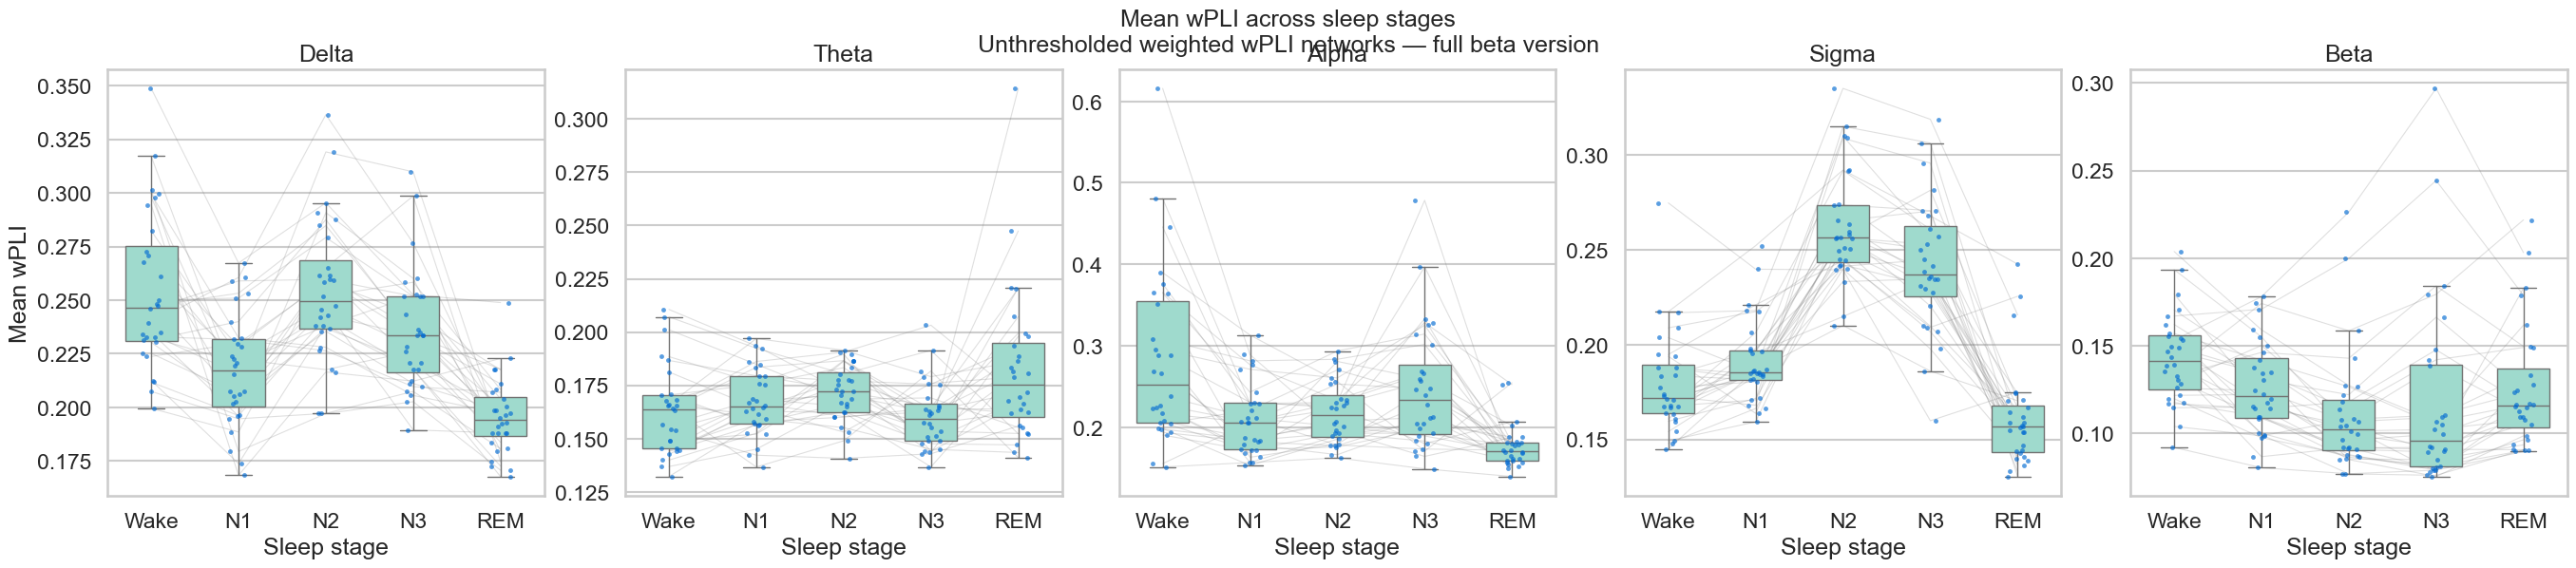

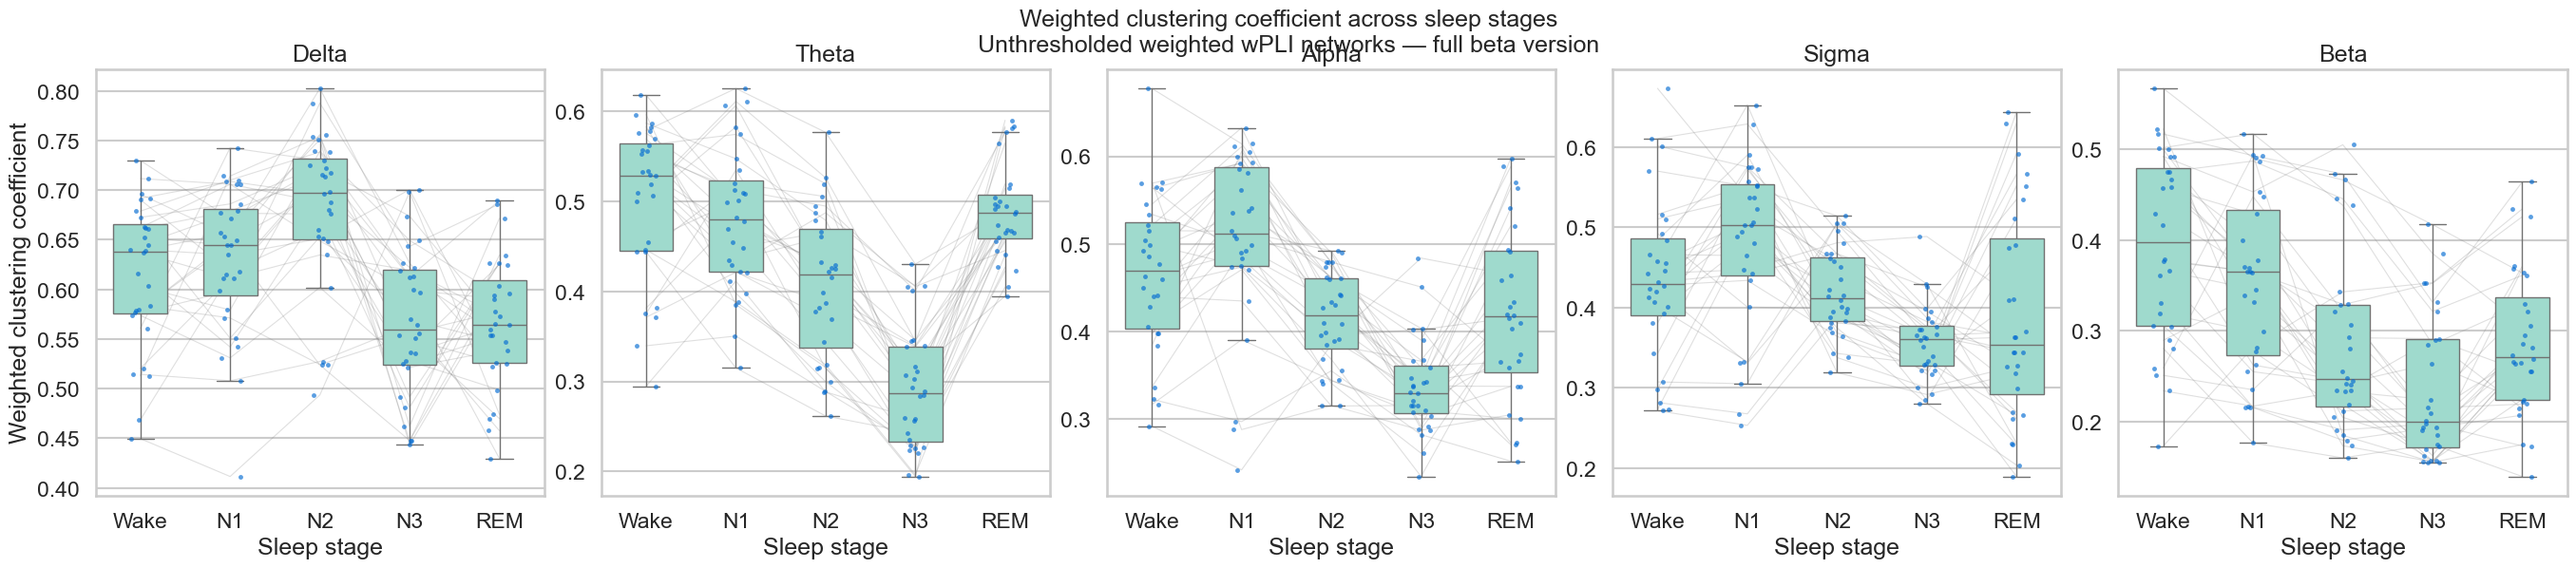

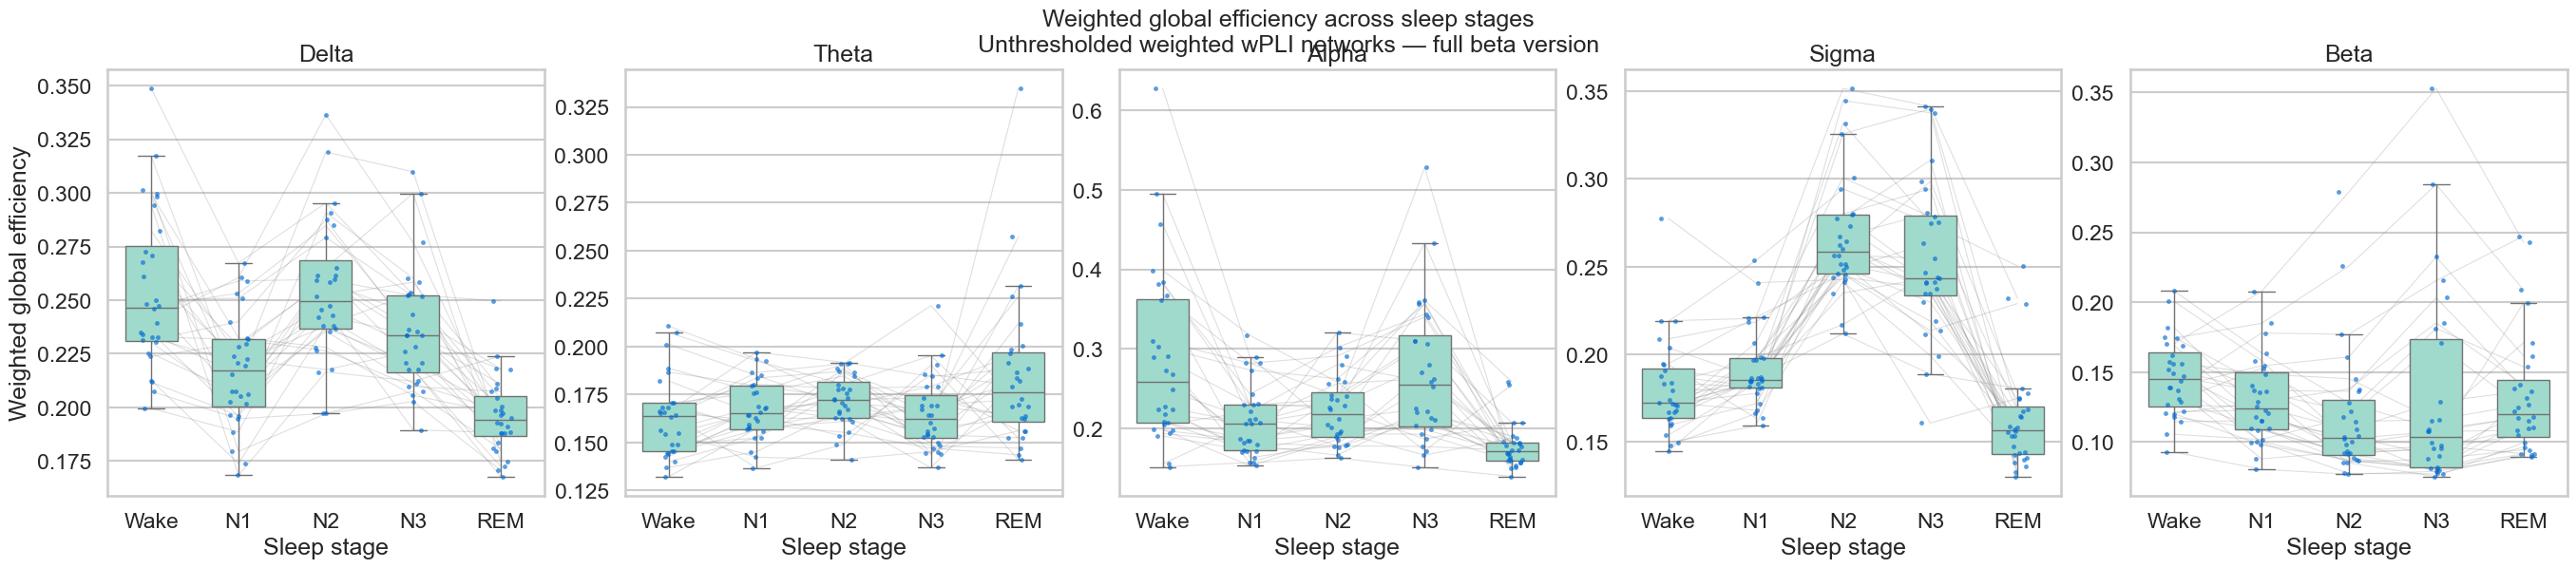

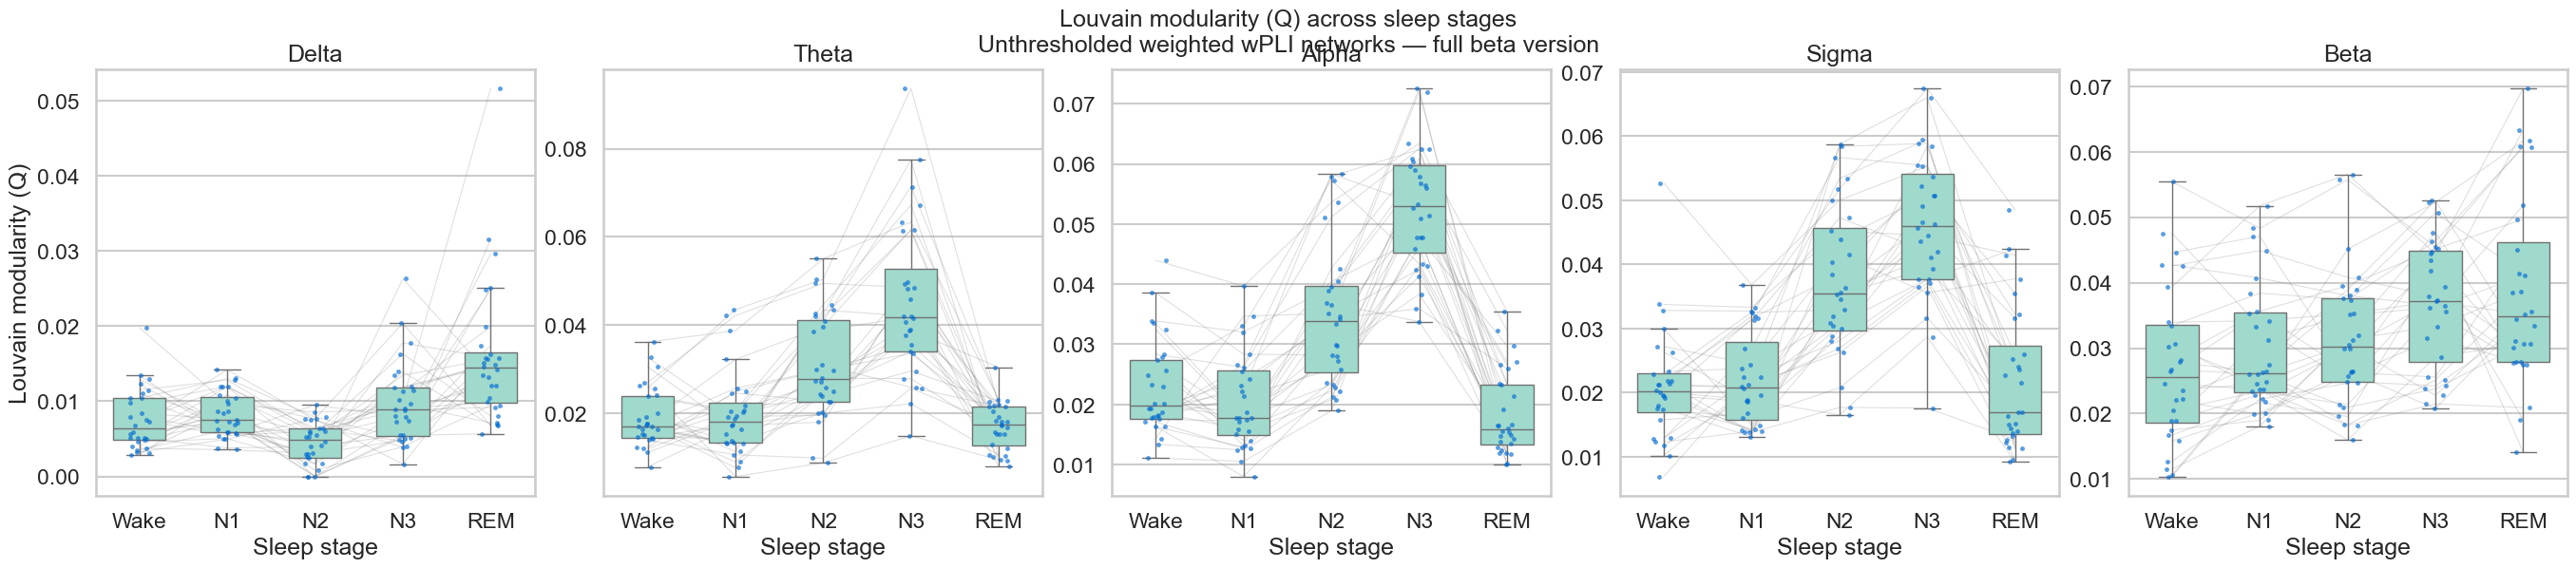

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid", context="talk")

PLOT_METRICS = {
    "mean_wpli": "Mean wPLI",
    "mean_weighted_clustering": "Weighted clustering coefficient",
    "weighted_global_efficiency": "Weighted global efficiency",
    "modularity_louvain": "Louvain modularity (Q)",
}

for metric_name, metric_label in PLOT_METRICS.items():

    fig, axes = plt.subplots(
        1,
        len(BAND_ORDER),
        figsize=(27, 5.5),
        constrained_layout=True,
    )

    for ax, band in zip(axes, BAND_ORDER):

        band_data = metrics_df.loc[
            metrics_df["band"] == band
        ].copy()

        if band_data.empty:
            ax.set_visible(False)
            continue

        # Individual participant trajectories, drawn first so they remain behind.
        for _, subject_data in band_data.groupby("subject_id"):
            subject_values = (
                subject_data
                .set_index("stage")[metric_name]
                .reindex(STAGE_ORDER)
            )

            ax.plot(
                np.arange(len(STAGE_ORDER)),
                subject_values,
                color="gray",
                alpha=0.25,
                linewidth=0.8,
                zorder=1,
            )

        sns.boxplot(
            data=band_data,
            x="stage",
            y=metric_name,
            order=STAGE_ORDER,
            ax=ax,
            color="#95e4d2",
            width=0.60,
            showfliers=False,
            zorder=2,
        )

        sns.stripplot(
            data=band_data,
            x="stage",
            y=metric_name,
            order=STAGE_ORDER,
            ax=ax,
            color="#016ad2",
            alpha=0.65,
            size=3.5,
            jitter=0.12,
            zorder=3,
        )

        ax.set_title(band.capitalize())
        ax.set_xlabel("Sleep stage")
        ax.set_ylabel(metric_label if band == BAND_ORDER[0] else "")

    fig.suptitle(
        f"{metric_label} across sleep stages\n"
        "Unthresholded weighted wPLI networks — full beta version",
        y=1.06,
        fontsize=18,
    )

    plt.show()

['EPCTL01', 'EPCTL02', 'EPCTL03', 'EPCTL04', 'EPCTL05', 'EPCTL06', 'EPCTL07', 'EPCTL09', 'EPCTL10', 'EPCTL11', 'EPCTL12', 'EPCTL13', 'EPCTL14', 'EPCTL15', 'EPCTL16', 'EPCTL17', 'EPCTL18', 'EPCTL19', 'EPCTL20', 'EPCTL21', 'EPCTL22', 'EPCTL23', 'EPCTL24', 'EPCTL25', 'EPCTL26', 'EPCTL27', 'EPCTL28', 'EPCTL29']
Number of subjects: 28


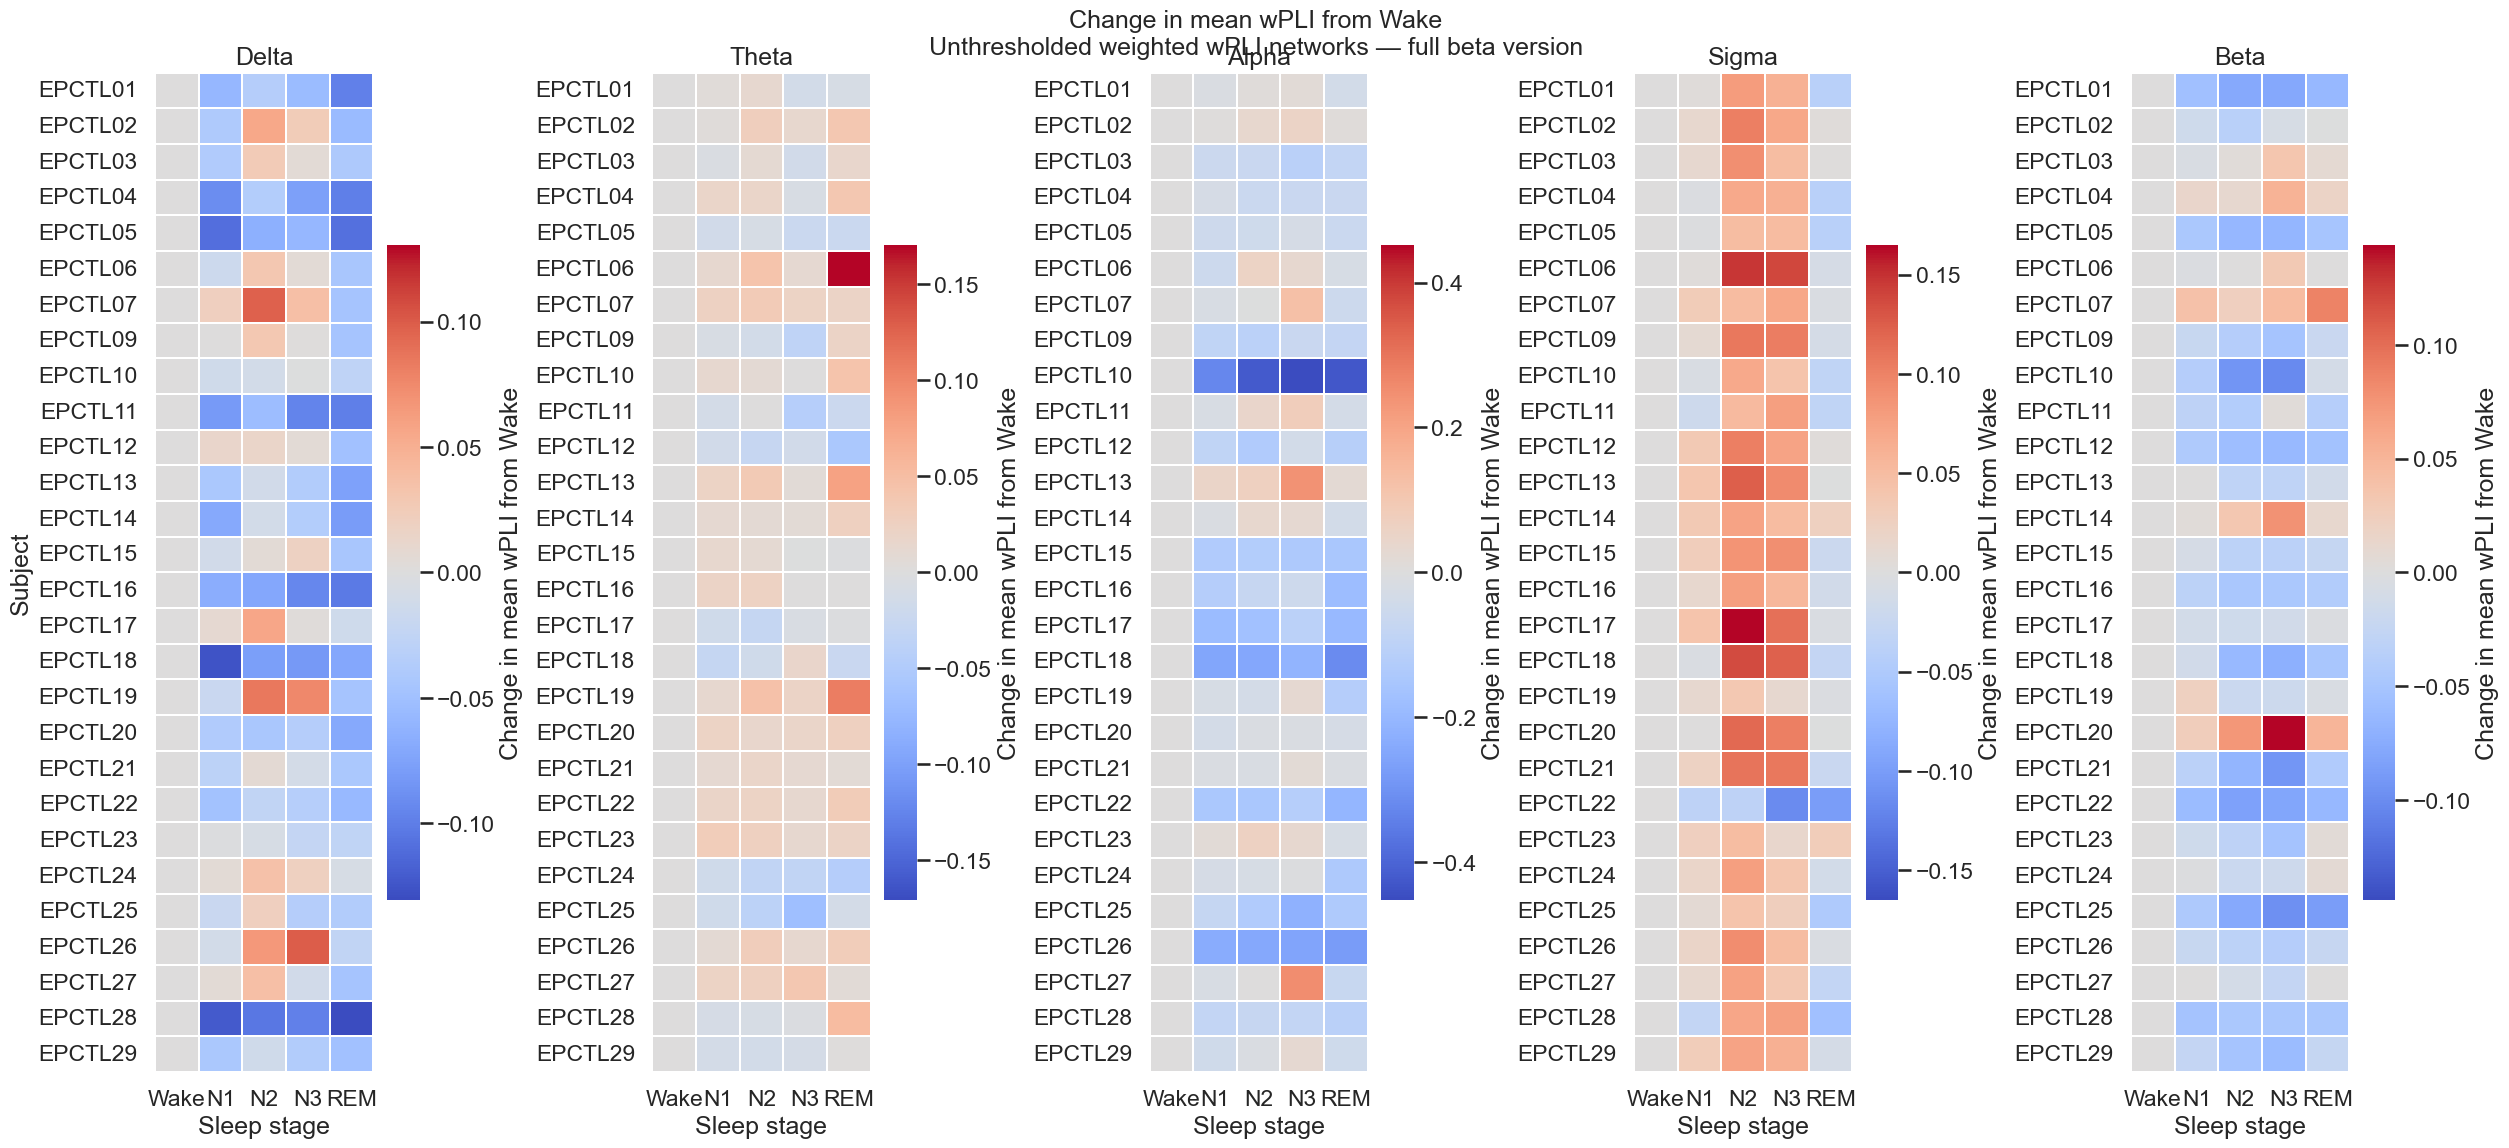

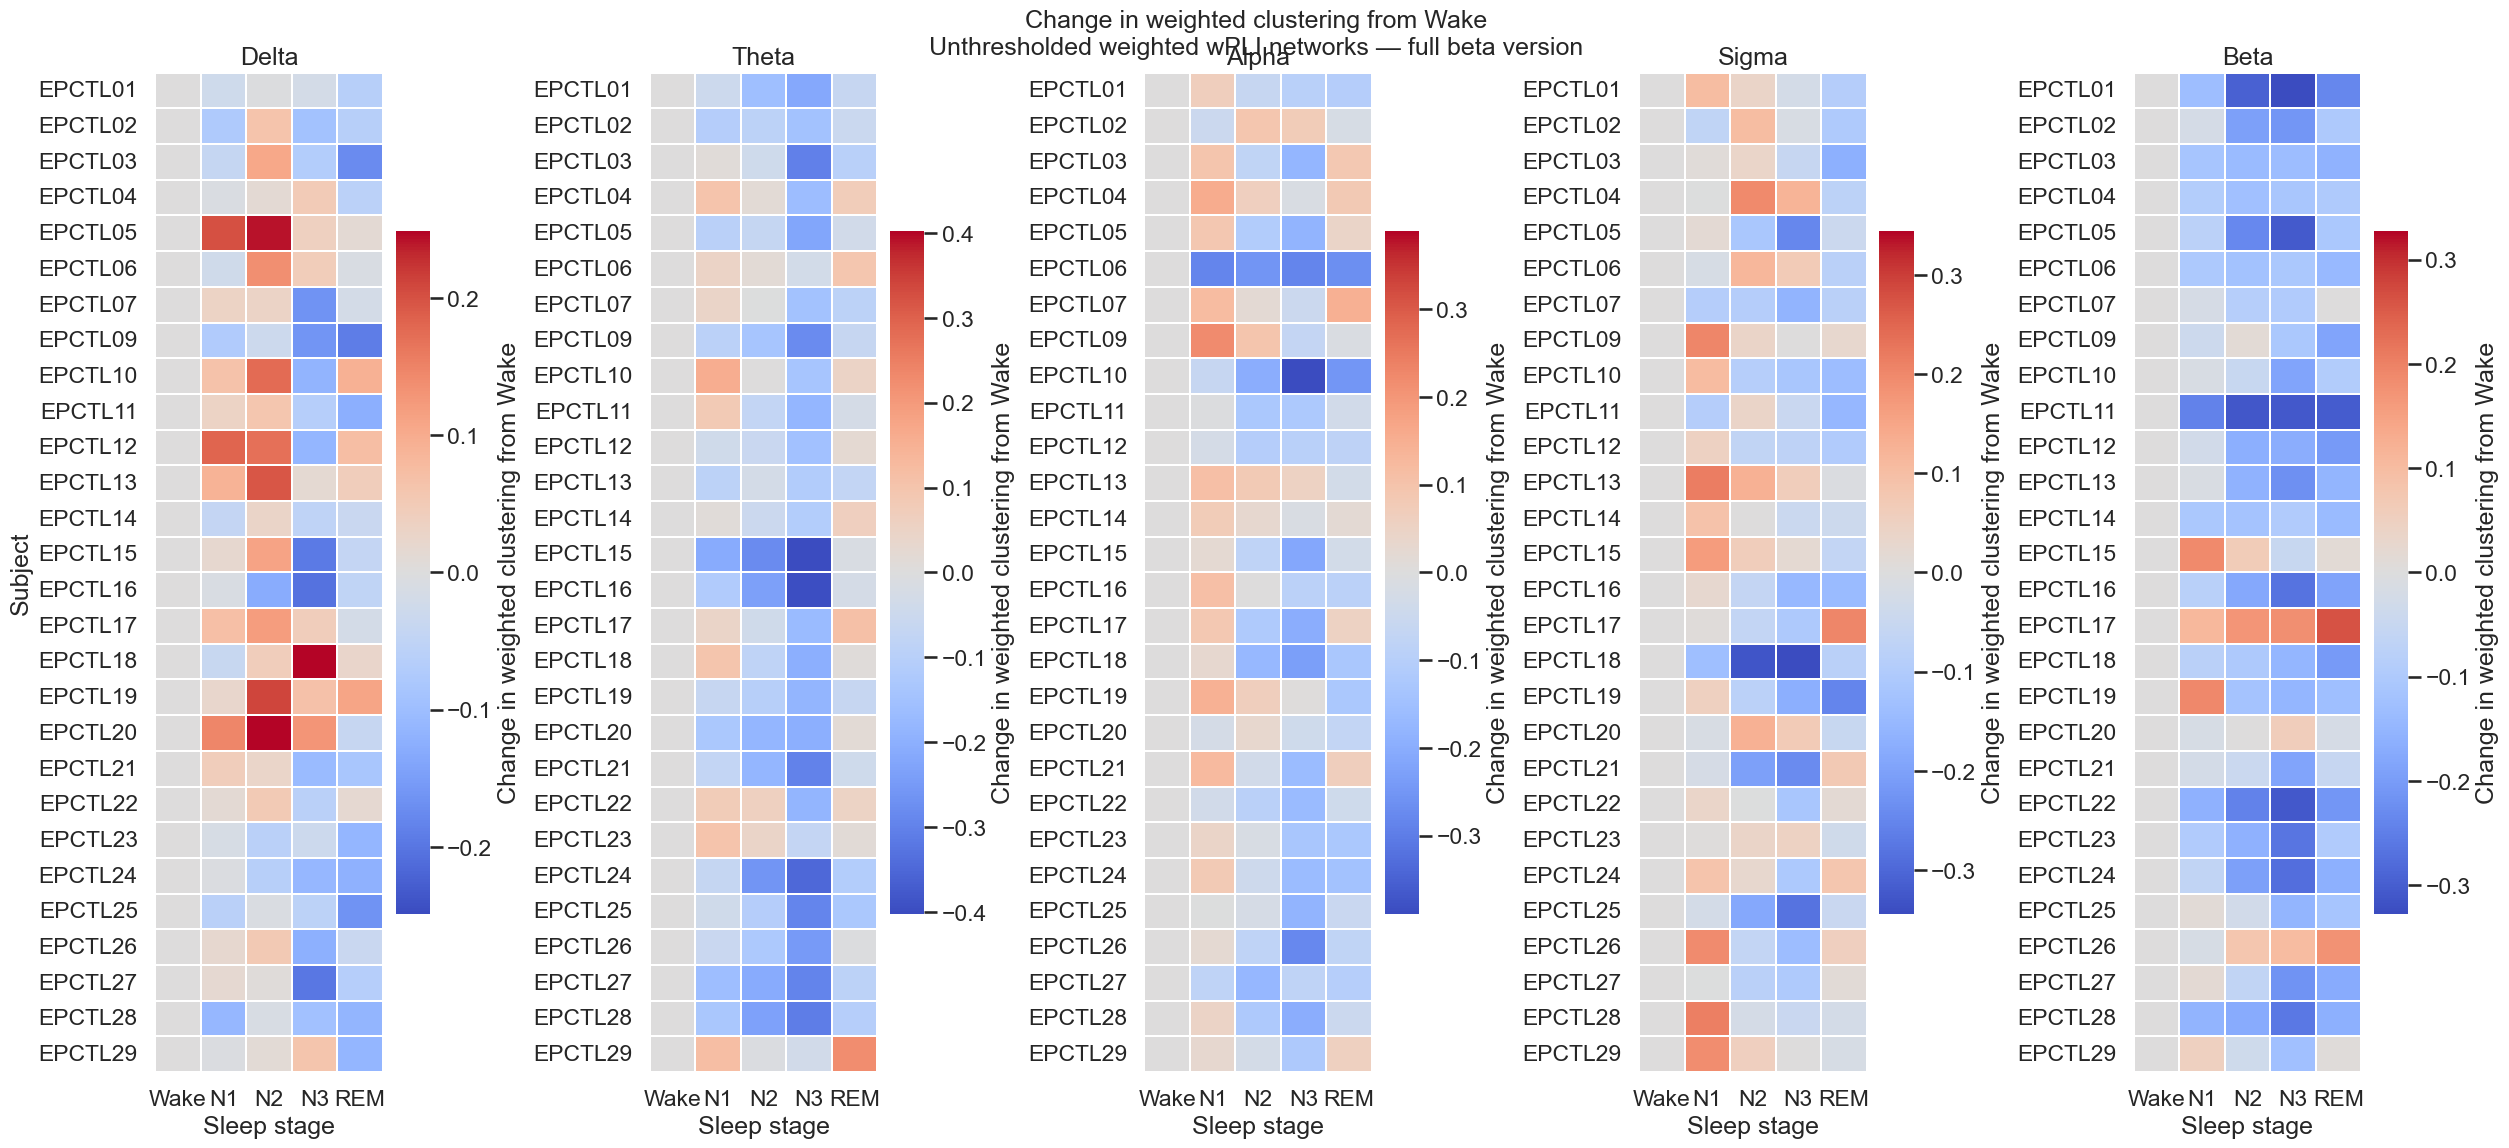

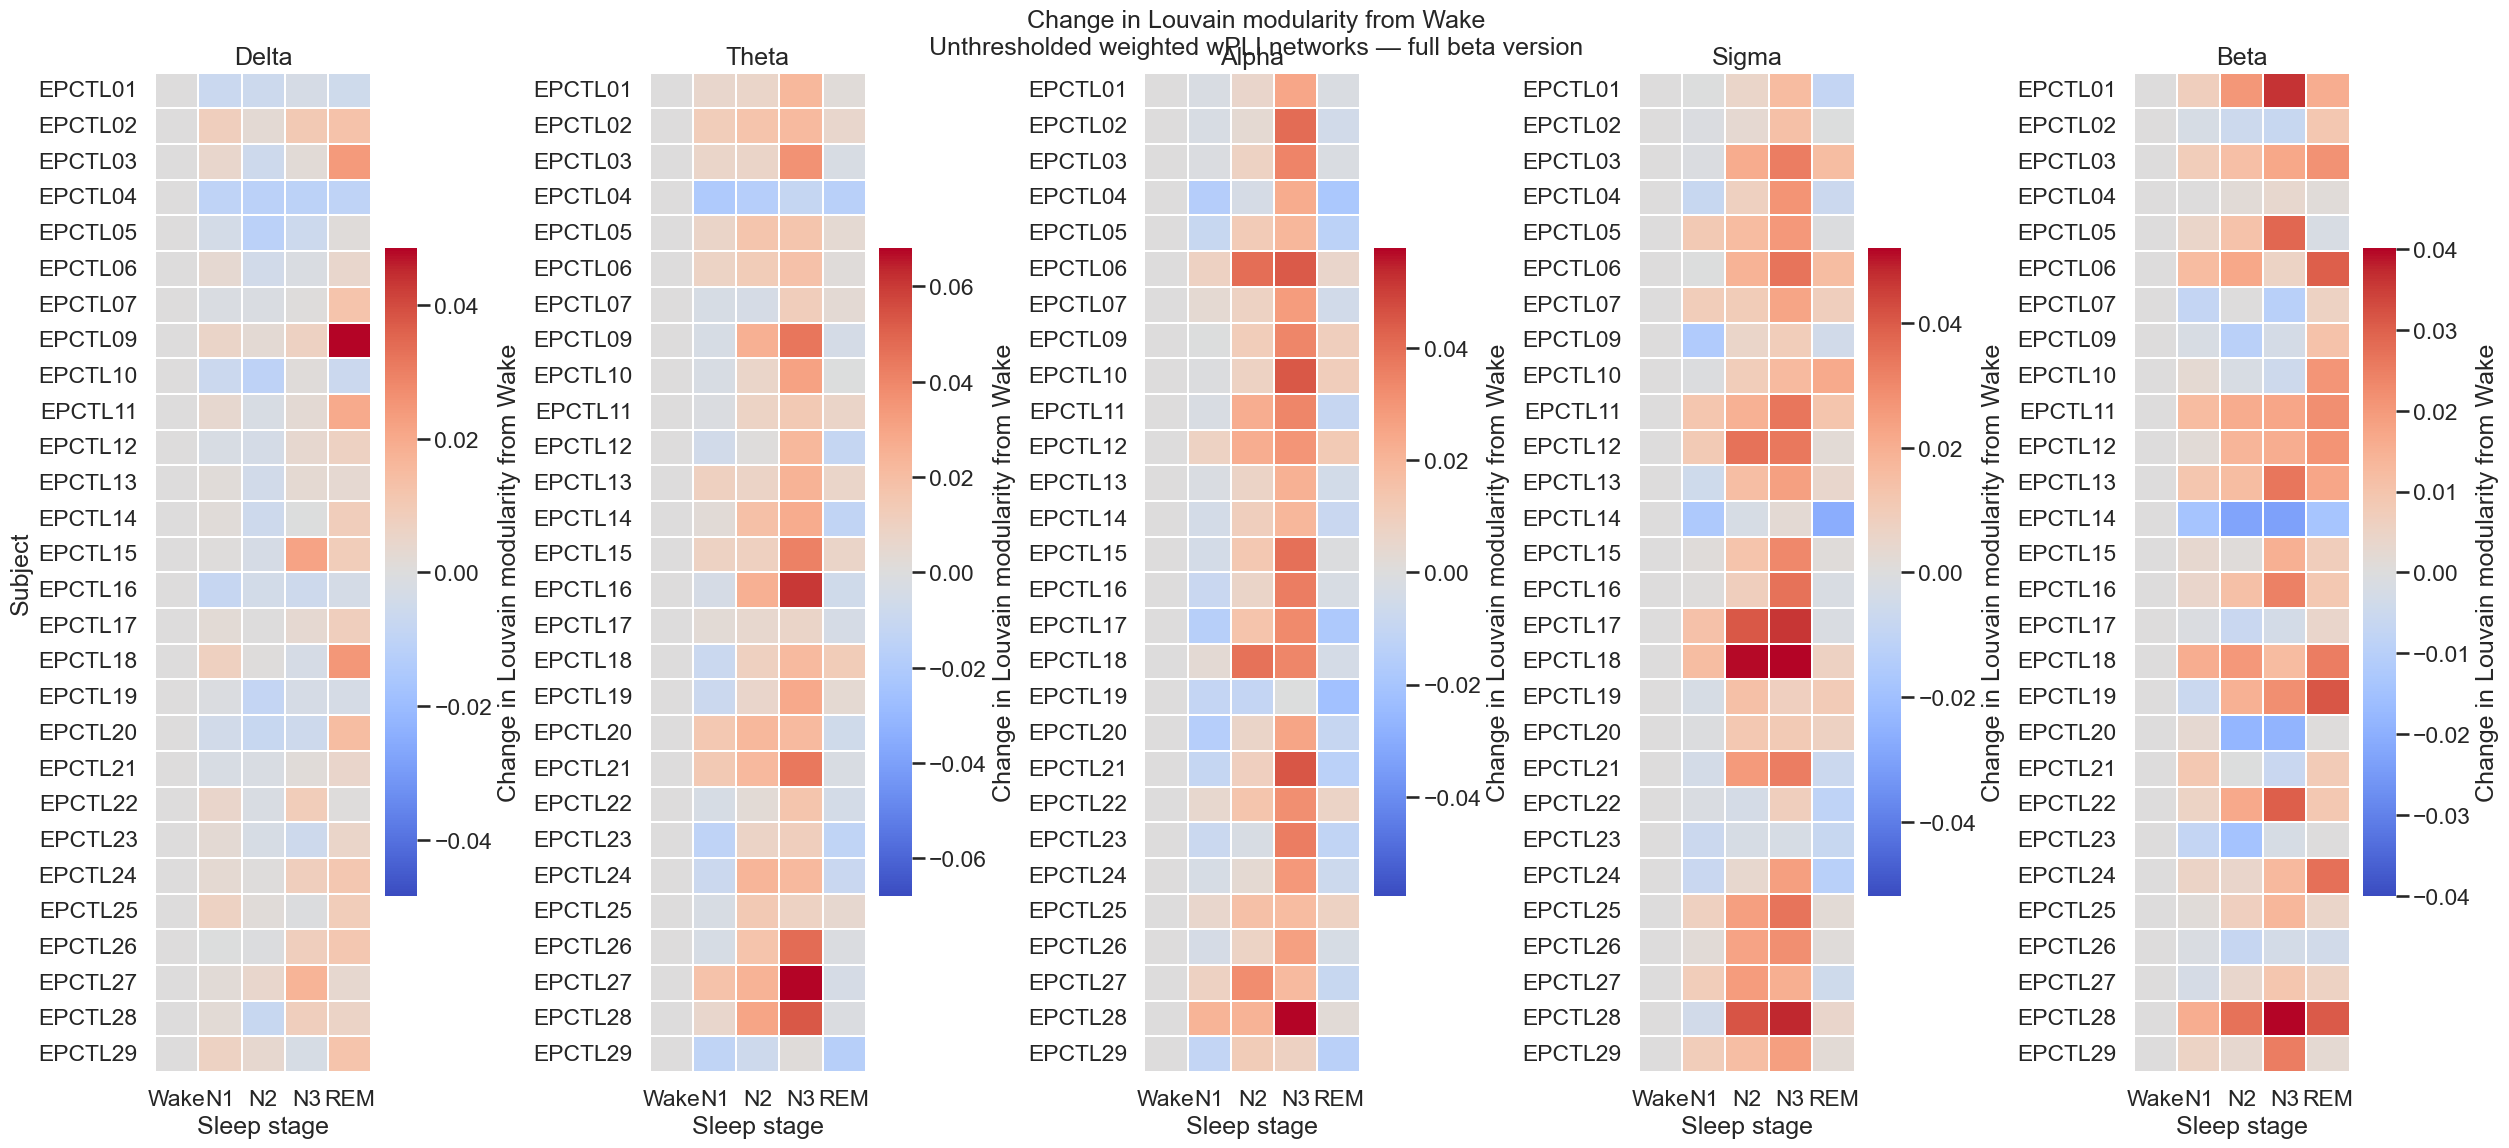

In [9]:
SUBJECT_ORDER = sorted(metrics_df["subject_id"].unique())

print(SUBJECT_ORDER)
print(f"Number of subjects: {len(SUBJECT_ORDER)}")

CHANGE_METRICS = {
    "mean_wpli": "Change in mean wPLI from Wake",
    "mean_weighted_clustering":
        "Change in weighted clustering from Wake",
    "modularity_louvain":
        "Change in Louvain modularity from Wake",
}

for metric_name, metric_label in CHANGE_METRICS.items():

    fig, axes = plt.subplots(
        1,
        len(BAND_ORDER),
        figsize=(25, 11),
        constrained_layout=True,
    )

    for ax, band in zip(axes, BAND_ORDER):

        band_data = metrics_df.loc[
            metrics_df["band"] == band
        ].copy()

        matrix = (
            band_data
            .pivot(
                index="subject_id",
                columns="stage",
                values=metric_name,
            )
            .reindex(
                index=SUBJECT_ORDER,
                columns=STAGE_ORDER,
            )
        )

        wake_values = matrix["Wake"]

        change_from_wake = matrix.subtract(
            wake_values,
            axis=0,
        )

        largest_absolute_change = np.nanmax(
            np.abs(change_from_wake.to_numpy())
        )

        sns.heatmap(
            change_from_wake,
            ax=ax,
            cmap="coolwarm",
            center=0,
            vmin=-largest_absolute_change,
            vmax=largest_absolute_change,
            linewidths=0.25,
            linecolor="white",
            cbar=True,
            cbar_kws={"label": metric_label},
        )

        ax.set_title(band.capitalize())
        ax.set_xlabel("Sleep stage")
        ax.set_ylabel("Subject" if band == BAND_ORDER[0] else "")

    fig.suptitle(
        f"{metric_label}\n"
        "Unthresholded weighted wPLI networks — full beta version",
        fontsize=18,
        y=1.03,
    )

    plt.show()

In [10]:
metrics_full = metrics_df.copy()

print(metrics_full["beta_edge_mode"].unique())

<StringArray>
['full']
Length: 1, dtype: str


In [11]:
#UNTHRESHOLDED METRICS CELL FOR WITHOUT BOTH-PERIPHERAL BETA VERSION
#CODE:MAIN DESCRIPTIVE STATIC-NETWORK ANALYSIS

from pathlib import Path
import time

import h5py
import numpy as np
import pandas as pd
import networkx as nx


# ------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------
STAGE_MEAN_DIR = Path(
    "../graphs_output/stage_mean_wpli_graphs_exclude_both_beta_peripheral"
)

STAGE_ORDER = ["Wake", "N1", "N2", "N3", "REM"]
BAND_ORDER = ["delta", "theta", "alpha", "sigma", "beta"]

# Fixed seed: makes Louvain results reproducible across reruns.
LOUVAIN_SEED = 42

# Use None for all subjects.
# For a speed test, change to 3.
MAX_SUBJECTS = None


# ------------------------------------------------------------------
# Locate input HDF5 files
# ------------------------------------------------------------------
all_stage_mean_paths = sorted(
    STAGE_MEAN_DIR.glob("*_stage_means.h5")
)

if not all_stage_mean_paths:
    raise FileNotFoundError(
        f"No '*_stage_means.h5' files found in:\n"
        f"{STAGE_MEAN_DIR.resolve()}"
    )

if MAX_SUBJECTS is None:
    stage_mean_paths = all_stage_mean_paths
else:
    stage_mean_paths = all_stage_mean_paths[:MAX_SUBJECTS]

print(f"Available subject files: {len(all_stage_mean_paths)}")
print(f"Subject files to process: {len(stage_mean_paths)}")


# ------------------------------------------------------------------
# Helpers
# ------------------------------------------------------------------
def decode_value(x):
    """Decode HDF5 byte strings when needed."""
    return x.decode() if isinstance(x, bytes) else str(x)


def prepare_adjacency(A):
    """
    Prepare one unthresholded weighted wPLI adjacency matrix.

    All positive wPLI edges are retained. No proportional or absolute
    threshold is applied.
    """
    A = np.asarray(A, dtype=float).copy()

    # Numerical safety: make symmetry exact and force zero diagonal.
    A = (A + A.T) / 2.0
    np.fill_diagonal(A, 0.0)

    if np.any(A < 0):
        raise ValueError("The adjacency matrix contains negative weights.")

    return A


def make_weighted_graph(A):
    """
    Create an undirected weighted NetworkX graph.

    weight   = wPLI connection strength
    distance = 1 / wPLI, used only for shortest-path metrics
    """
    G = nx.from_numpy_array(A)

    for u, v, data in G.edges(data=True):
        wpli = data["weight"]

        if wpli <= 0:
            raise ValueError("A retained edge has non-positive wPLI.")

        data["distance"] = 1.0 / wpli

    return G


def weighted_path_metrics(G):
    """
    Calculate weighted global efficiency and weighted characteristic
    path length from ONE shared all-pairs shortest-path calculation.

    This is faster than calculating shortest paths separately for each metric.
    """
    nodes = list(G.nodes())

    if len(nodes) < 2:
        return np.nan, np.nan

    shortest_paths = dict(
        nx.all_pairs_dijkstra_path_length(G, weight="distance")
    )

    efficiencies = []
    finite_distances = []

    for i, source in enumerate(nodes):
        for target in nodes[i + 1:]:

            distance = shortest_paths[source].get(target, np.inf)

            if np.isfinite(distance) and distance > 0:
                efficiencies.append(1.0 / distance)
                finite_distances.append(distance)

            else:
                # A disconnected pair contributes zero to global efficiency.
                efficiencies.append(0.0)

    weighted_global_efficiency = float(np.mean(efficiencies))

    weighted_characteristic_path_length = (
        float(np.mean(finite_distances))
        if finite_distances
        else np.nan
    )

    return (
        weighted_global_efficiency,
        weighted_characteristic_path_length,
    )


def compute_unthresholded_metrics(A, seed=42):
    """
    Compute static weighted metrics for one unthresholded mean wPLI graph.
    """
    A = prepare_adjacency(A)
    G = make_weighted_graph(A)

    # Mean wPLI: upper triangle only, avoiding diagonal and duplicate edges.
    upper_triangle = A[np.triu_indices_from(A, k=1)]
    nonzero_weights = upper_triangle[upper_triangle > 0]

    # Mean node strength.
    strengths = np.array(
        [strength for _, strength in G.degree(weight="weight")],
        dtype=float,
    )

    # Both metrics use the same shortest-path calculation.
    global_efficiency, characteristic_path_length = weighted_path_metrics(G)

    # Graph connectedness: mainly quality-control information.
    components = list(nx.connected_components(G))
    largest_component = max(components, key=len)

    # Weighted community organization.
    try:
        communities = nx.community.louvain_communities(
            G,
            weight="weight",
            seed=seed,
        )

        modularity = nx.community.modularity(
            G,
            communities,
            weight="weight",
        )

        n_communities = len(communities)

    except Exception as error:
        print(f"Warning: Louvain failed: {error}")
        modularity = np.nan
        n_communities = np.nan

    return {
        # Overall connectivity strength
        "mean_wpli": float(np.mean(upper_triangle)),
        "mean_node_strength": float(np.mean(strengths)),

        # Local segregation
        "mean_weighted_clustering": float(
            nx.average_clustering(G, weight="weight")
        ),

        # Global integration
        "weighted_global_efficiency": global_efficiency,
        "weighted_characteristic_path_length":
            characteristic_path_length,

        # Community organization
        "modularity_louvain": modularity,
        "n_louvain_communities": n_communities,

        # Quality-control fields
        "n_nodes": G.number_of_nodes(),
        "n_edges": G.number_of_edges(),
        "edge_density": nx.density(G),
        "n_connected_components": len(components),
        "largest_component_size": len(largest_component),
        "minimum_nonzero_wpli": (
            float(nonzero_weights.min())
            if len(nonzero_weights) > 0
            else np.nan
        ),
    }


# ------------------------------------------------------------------
# Compute static metrics: one row per subject × band × stage graph
# ------------------------------------------------------------------
rows = []

start_time = time.perf_counter()
graphs_completed = 0

for subject_number, h5_path in enumerate(stage_mean_paths, start=1):

    subject_start_time = time.perf_counter()

    with h5py.File(h5_path, "r") as f:
        subject_id = decode_value(f.attrs["subject_id"])
        beta_edge_mode = decode_value(f.attrs["beta_edge_mode"])

        bands_in_file = [decode_value(x) for x in f.attrs["bands"]]
        stages_in_file = [decode_value(x) for x in f.attrs["stages"]]

        bands = [band for band in BAND_ORDER if band in bands_in_file]
        stages = [stage for stage in STAGE_ORDER if stage in stages_in_file]

        for band in bands:
            for stage in stages:

                if stage not in f[band]:
                    continue

                A = f[band][stage][:]

                graph_metrics = compute_unthresholded_metrics(
                    A,
                    seed=LOUVAIN_SEED,
                )

                rows.append({
                    "subject_id": subject_id,
                    "band": band,
                    "stage": stage,
                    "beta_edge_mode": beta_edge_mode,
                    "n_epochs_averaged": int(
                        f[band][stage].attrs["n_epochs_averaged"]
                    ),
                    **graph_metrics,
                })

                graphs_completed += 1

    subject_elapsed = time.perf_counter() - subject_start_time

    print(
        f"[{subject_number}/{len(stage_mean_paths)}] "
        f"{subject_id}: finished in {subject_elapsed:.1f} s "
        f"({graphs_completed} graphs total)"
    )


# ------------------------------------------------------------------
# Runtime summary
# ------------------------------------------------------------------
metrics_df = pd.DataFrame(rows)

# Preserve this version separately before any later rerun overwrites metrics_df.
metrics_excluded = metrics_df.copy()

print("Beta mode in this table:")
print(metrics_excluded["beta_edge_mode"].unique())

total_elapsed_seconds = time.perf_counter() - start_time
total_elapsed_minutes = total_elapsed_seconds / 60

print("\n" + "=" * 65)
print("STATIC TOPOLOGY METRICS COMPLETE")
print("=" * 65)
print(f"Graphs processed: {len(metrics_df)}")
print(f"Elapsed time: {total_elapsed_minutes:.2f} minutes")

if len(metrics_df) > 0:
    seconds_per_graph = total_elapsed_seconds / len(metrics_df)
    print(f"Mean time per graph: {seconds_per_graph:.3f} seconds")

if MAX_SUBJECTS is not None and MAX_SUBJECTS < len(all_stage_mean_paths):
    estimated_full_minutes = (
        total_elapsed_minutes
        * len(all_stage_mean_paths)
        / len(stage_mean_paths)
    )

    print(
        f"Estimated runtime for all {len(all_stage_mean_paths)} subjects: "
        f"{estimated_full_minutes:.2f} minutes"
    )

print("\nMetrics-table preview:")
display(metrics_df.head())

Available subject files: 28
Subject files to process: 28
[1/28] EPCTL01: finished in 23.5 s (25 graphs total)
[2/28] EPCTL02: finished in 23.3 s (50 graphs total)
[3/28] EPCTL03: finished in 24.1 s (75 graphs total)
[4/28] EPCTL04: finished in 23.3 s (100 graphs total)
[5/28] EPCTL05: finished in 24.4 s (125 graphs total)
[6/28] EPCTL06: finished in 18.9 s (150 graphs total)
[7/28] EPCTL07: finished in 16.5 s (175 graphs total)
[8/28] EPCTL09: finished in 20.1 s (200 graphs total)
[9/28] EPCTL10: finished in 24.5 s (225 graphs total)
[10/28] EPCTL11: finished in 24.8 s (250 graphs total)
[11/28] EPCTL12: finished in 31.5 s (275 graphs total)
[12/28] EPCTL13: finished in 27.9 s (300 graphs total)
[13/28] EPCTL14: finished in 27.9 s (325 graphs total)
[14/28] EPCTL15: finished in 27.5 s (350 graphs total)
[15/28] EPCTL16: finished in 28.1 s (375 graphs total)
[16/28] EPCTL17: finished in 28.6 s (400 graphs total)
[17/28] EPCTL18: finished in 28.2 s (425 graphs total)
[18/28] EPCTL19: fin

,subject_id,band,stage,beta_edge_mode,n_epochs_averaged,mean_wpli,mean_node_strength,mean_weighted_clustering,weighted_global_efficiency,weighted_characteristic_path_length,modularity_louvain,n_louvain_communities,n_nodes,n_edges,edge_density,n_connected_components,largest_component_size,minimum_nonzero_wpli
0,EPCTL01,delta,Wake,exclude_both_peripheral,46,0.282302,23.148764,0.637209,0.282303,3.594876,0.012292,2,83,3403,1.0,1,83,0.185368
1,EPCTL01,delta,N1,exclude_both_peripheral,74,0.223924,18.361749,0.611254,0.223928,4.573148,0.005771,3,83,3403,1.0,1,83,0.144513
2,EPCTL01,delta,N2,exclude_both_peripheral,471,0.247354,20.283053,0.634753,0.247354,4.114332,0.006388,2,83,3403,1.0,1,83,0.175895
3,EPCTL01,delta,N3,exclude_both_peripheral,185,0.228114,18.705349,0.619244,0.228114,4.440453,0.009635,3,83,3403,1.0,1,83,0.169799
4,EPCTL01,delta,REM,exclude_both_peripheral,176,0.183787,15.070567,0.573329,0.183787,5.488255,0.007144,2,83,3403,1.0,1,83,0.135982


In [12]:
#BETA-ONLY COMPARISON

print("Full version:")
print(metrics_full["beta_edge_mode"].unique())

print("\nExcluded version:")
print(metrics_excluded["beta_edge_mode"].unique())

print("\nFull-table rows:", len(metrics_full))
print("Excluded-table rows:", len(metrics_excluded))

Full version:
<StringArray>
['full']
Length: 1, dtype: str

Excluded version:
<StringArray>
['exclude_both_peripheral']
Length: 1, dtype: str

Full-table rows: 700
Excluded-table rows: 700


In [13]:
# PAIRED SCATTERPLOTS FOR THE BETA-ONLY COMPARISON

COMPARE_METRICS = [
    "mean_wpli",
    "mean_weighted_clustering",
    "modularity_louvain",
]

full_beta = metrics_full.loc[
    metrics_full["band"] == "beta"
].copy()

excluded_beta = metrics_excluded.loc[
    metrics_excluded["band"] == "beta"
].copy()

beta_comparison = full_beta.merge(
    excluded_beta,
    on=["subject_id", "stage"],
    suffixes=("_full", "_excluded"),
)

for metric in COMPARE_METRICS:
    beta_comparison[f"{metric}_difference"] = (
        beta_comparison[f"{metric}_excluded"]
        - beta_comparison[f"{metric}_full"]
    )

display(beta_comparison.head())

,subject_id,band_full,stage,beta_edge_mode_full,n_epochs_averaged_full,mean_wpli_full,mean_node_strength_full,mean_weighted_clustering_full,weighted_global_efficiency_full,weighted_characteristic_path_length_full,...,n_louvain_communities_excluded,n_nodes_excluded,n_edges_excluded,edge_density_excluded,n_connected_components_excluded,largest_component_size_excluded,minimum_nonzero_wpli_excluded,mean_wpli_difference,mean_weighted_clustering_difference,modularity_louvain_difference
0,EPCTL01,beta,Wake,full,46,0.154211,12.645282,0.499691,0.155684,6.631096,...,3,83,3172,0.932119,1,83,0.077787,-0.009884,-0.022330,-0.001411
1,EPCTL01,beta,N1,full,74,0.099141,8.129530,0.368976,0.099263,10.448331,...,3,83,3172,0.932119,1,83,0.057858,-0.007941,0.096106,-0.009797
2,EPCTL01,beta,N2,full,471,0.076829,6.299943,0.204616,0.077580,13.302258,...,3,83,3172,0.932119,1,83,0.060102,-0.007718,0.300693,-0.023134
3,EPCTL01,beta,N3,full,185,0.075992,6.231381,0.172397,0.077203,13.679373,...,4,83,3172,0.932119,1,83,0.054432,-0.009120,0.105019,-0.032711
4,EPCTL01,beta,REM,full,176,0.090570,7.426735,0.263518,0.090712,11.358302,...,4,83,3172,0.932119,1,83,0.063654,-0.007672,0.219305,-0.003832


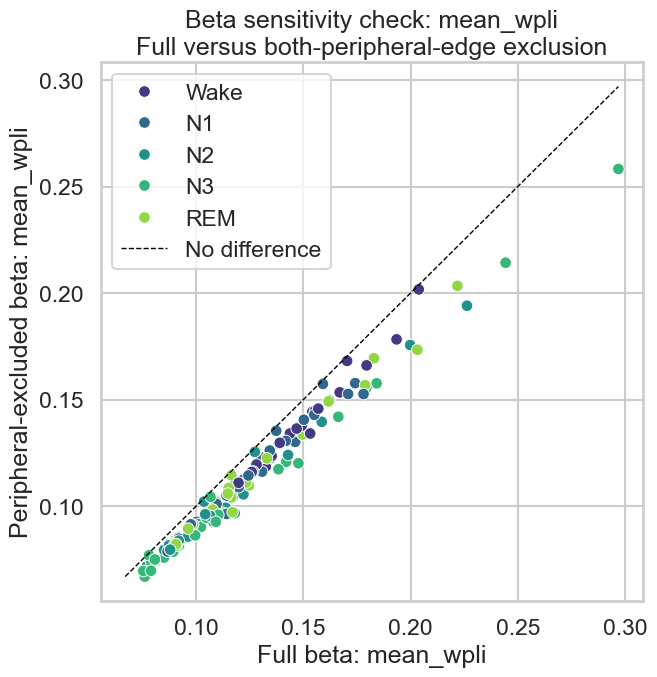

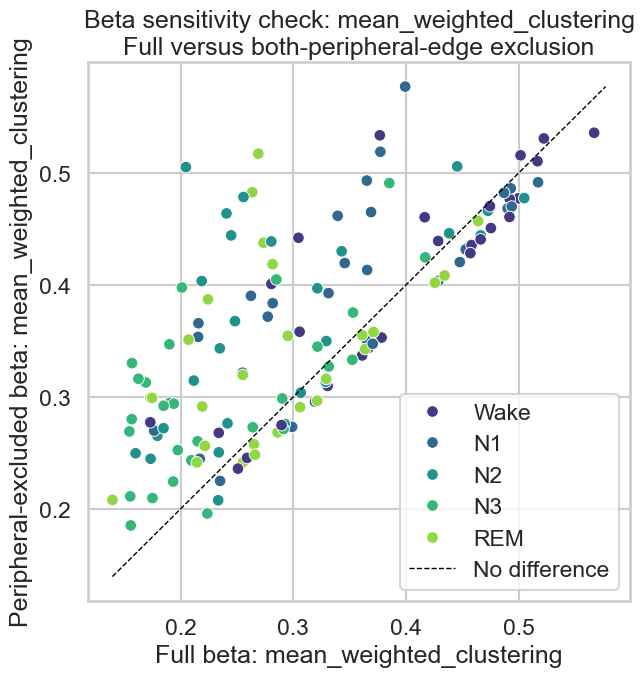

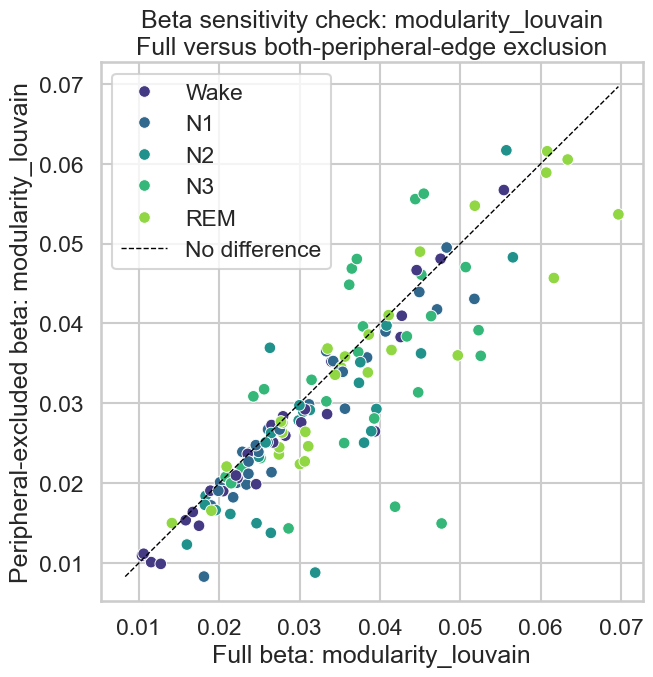

In [14]:
#PAIRED SCATTERPLOTS FOR THE BETA-ONLY COMPARISON:

sns.set_theme(style="whitegrid", context="talk")

for metric in COMPARE_METRICS:

    x = beta_comparison[f"{metric}_full"]
    y = beta_comparison[f"{metric}_excluded"]

    lower = min(x.min(), y.min())
    upper = max(x.max(), y.max())

    plt.figure(figsize=(7, 7))

    sns.scatterplot(
        data=beta_comparison,
        x=f"{metric}_full",
        y=f"{metric}_excluded",
        hue="stage",
        palette="viridis",
        s=70,
    )

    plt.plot(
        [lower, upper],
        [lower, upper],
        linestyle="--",
        color="black",
        linewidth=1,
        label="No difference",
    )

    plt.xlabel(f"Full beta: {metric}")
    plt.ylabel(f"Peripheral-excluded beta: {metric}")
    plt.title(
        f"Beta sensitivity check: {metric}\n"
        "Full versus both-peripheral-edge exclusion"
    )

    plt.legend()
    plt.show()

Beta-band graphs were analysed primarily after exclusion of edges connecting two validated peripheral electrodes. This targeted correction was motivated by prior peripheral-edge quality-control findings and preserved all nodes and all non-peripheral beta edges. Full beta-band graphs were retained as a sensitivity analysis. Comparison of the two pipelines showed near-identical overall beta connectivity rankings but greater sensitivity of local topology, particularly weighted clustering, to the peripheral-edge decision.
Your comparison does not establish that. At most, you can say they were potentially less reliable peripheral beta edges or that they had a disproportionate influence on beta topology.
Beta-frequency EEG can be vulnerable to peripheral muscle/electrode-related contamination, but direct proof would require additional evidence such as EMG–connectivity associations, raw-signal inspection, or a dedicated artifact analysis. Your pipeline already includes artifact handling and chin-EMG regression, so this exclusion should be described as a conservative additional sensitivity-motivated correction rather than proof of residual muscle activity.

In [15]:
metrics_to_plot = metrics_excluded.copy()

print(metrics_to_plot["beta_edge_mode"].unique())

<StringArray>
['exclude_both_peripheral']
Length: 1, dtype: str


Beta mode plotted:
<StringArray>
['exclude_both_peripheral']
Length: 1, dtype: str


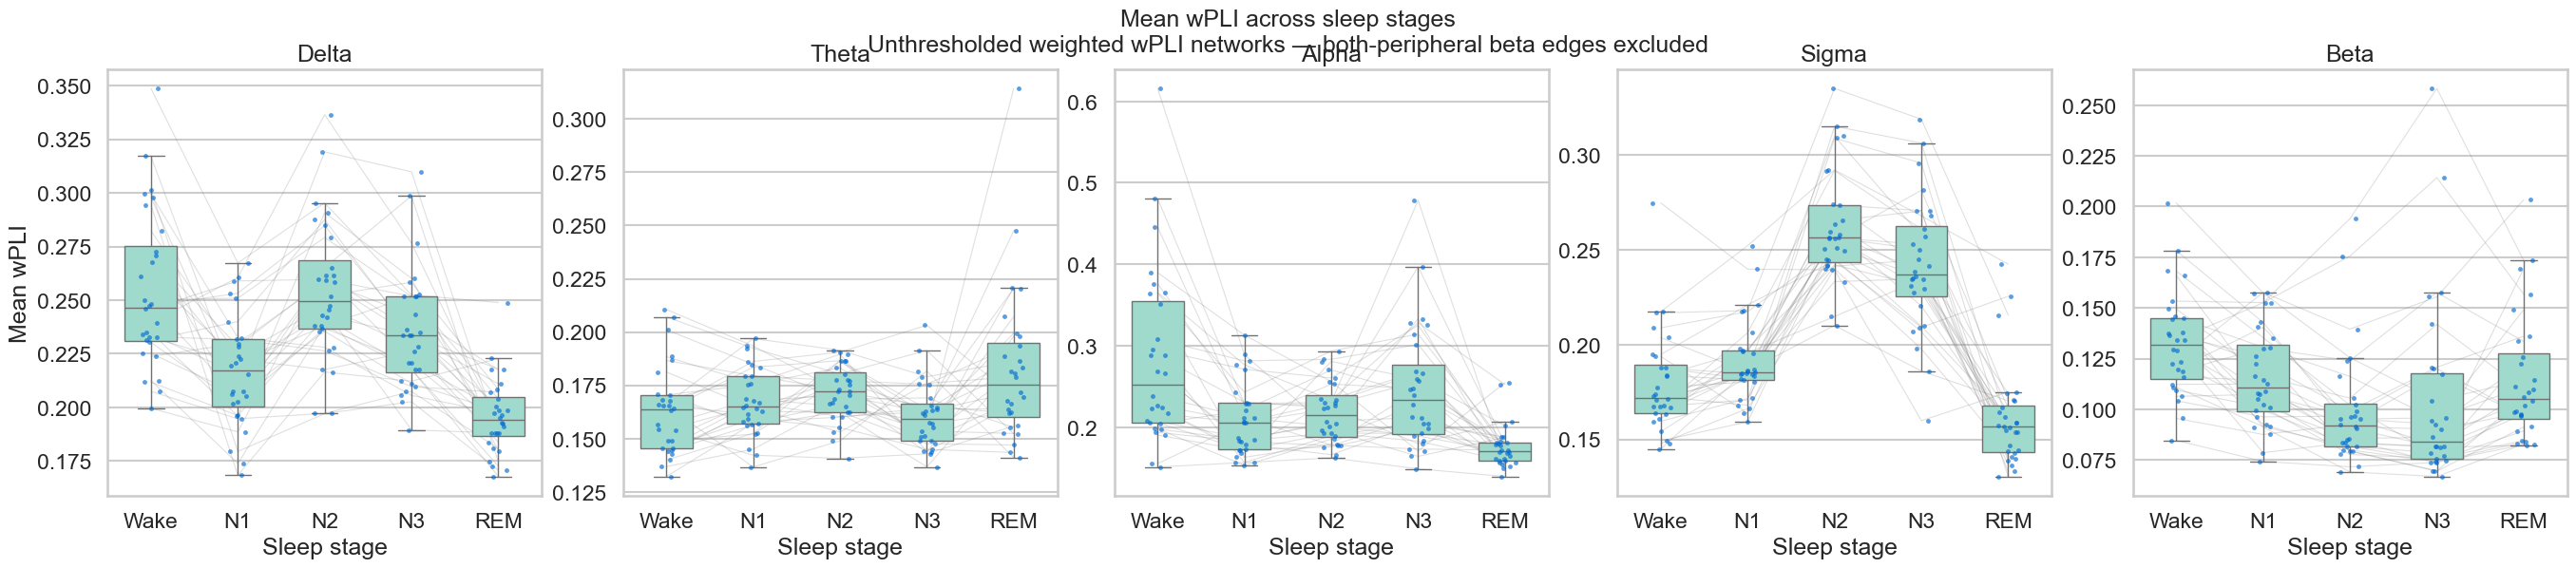

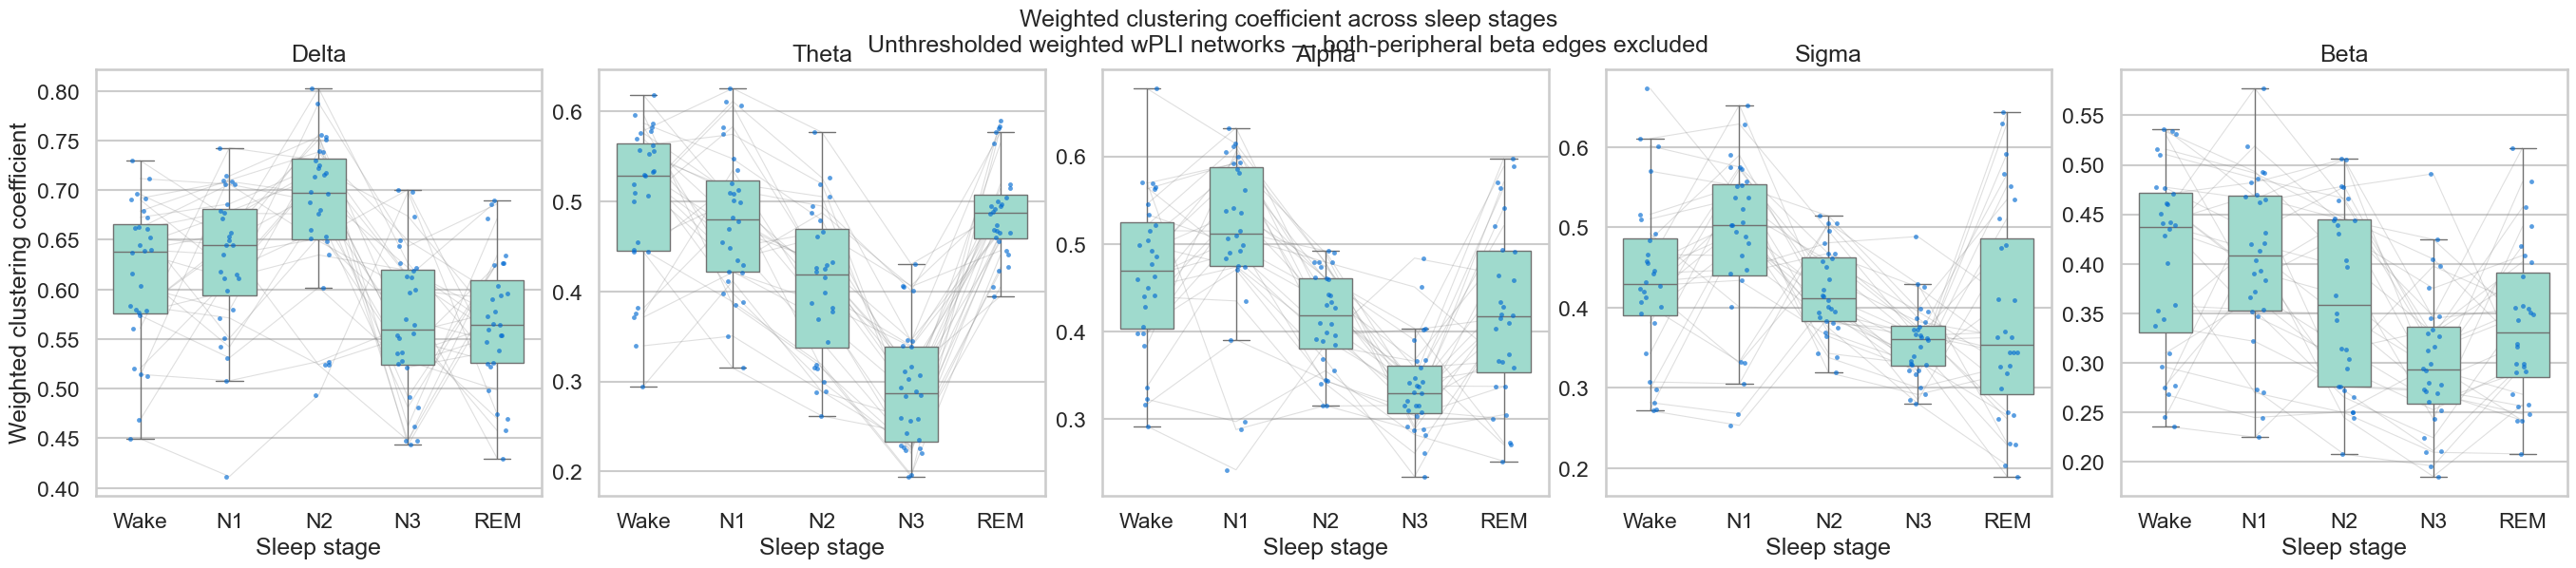

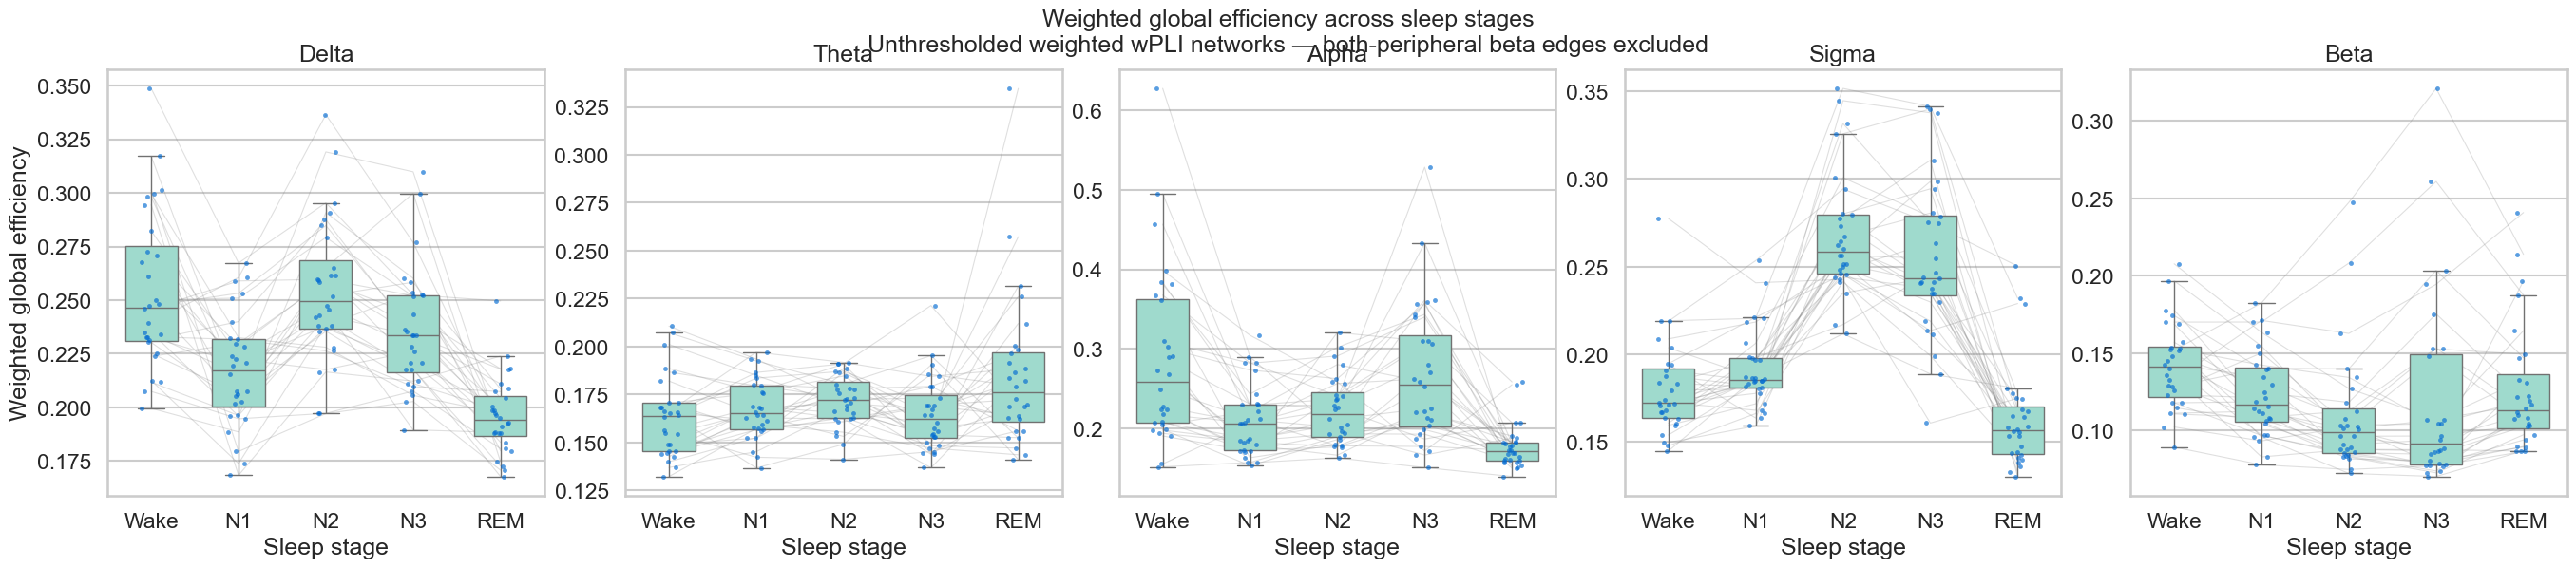

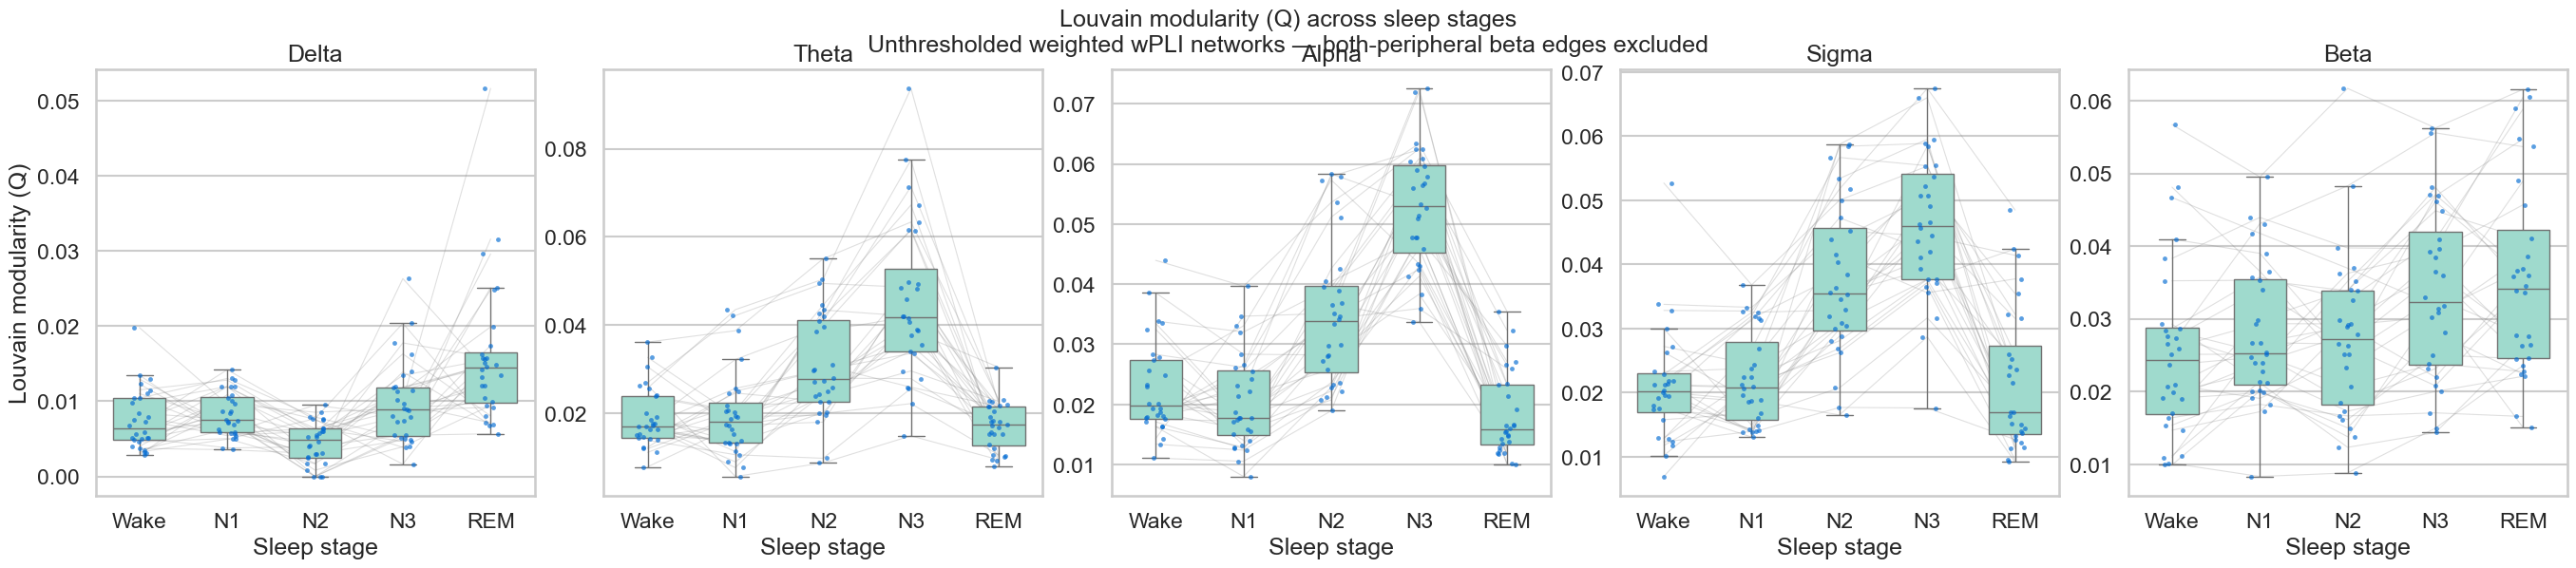

In [16]:
#UNTHRESHOLDED METRICS CELL FOR WITHOUT BOTH-PERIPHERAL BETA VERSION
# PLOTTING: MAIN DESCRIPTIVE STATIC-NETWORK ANALYSIS

sns.set_theme(style="whitegrid", context="talk")

metrics_to_plot = metrics_excluded.copy()

print("Beta mode plotted:")
print(metrics_to_plot["beta_edge_mode"].unique())


PLOT_METRICS = {
    "mean_wpli": "Mean wPLI",
    "mean_weighted_clustering": "Weighted clustering coefficient",
    "weighted_global_efficiency": "Weighted global efficiency",
    "modularity_louvain": "Louvain modularity (Q)",
}


for metric_name, metric_label in PLOT_METRICS.items():

    fig, axes = plt.subplots(
        1,
        len(BAND_ORDER),
        figsize=(27, 5.5),
        constrained_layout=True,
    )

    for ax, band in zip(axes, BAND_ORDER):

        band_data = metrics_to_plot.loc[
            metrics_to_plot["band"] == band
        ].copy()

        if band_data.empty:
            ax.set_visible(False)
            continue

        for _, subject_data in band_data.groupby("subject_id"):

            subject_values = (
                subject_data
                .set_index("stage")[metric_name]
                .reindex(STAGE_ORDER)
            )

            ax.plot(
                np.arange(len(STAGE_ORDER)),
                subject_values,
                color="gray",
                alpha=0.25,
                linewidth=0.8,
                zorder=1,
            )

        sns.boxplot(
            data=band_data,
            x="stage",
            y=metric_name,
            order=STAGE_ORDER,
            ax=ax,
            color="#95e4d2",
            width=0.60,
            showfliers=False,
            zorder=2,
        )

        sns.stripplot(
            data=band_data,
            x="stage",
            y=metric_name,
            order=STAGE_ORDER,
            ax=ax,
            color="#016ad2",
            alpha=0.65,
            size=3.5,
            jitter=0.12,
            zorder=3,
        )

        ax.set_title(band.capitalize())
        ax.set_xlabel("Sleep stage")
        ax.set_ylabel(
            metric_label if band == BAND_ORDER[0] else ""
        )

    fig.suptitle(
        f"{metric_label} across sleep stages\n"
        "Unthresholded weighted wPLI networks — "
        "both-peripheral beta edges excluded",
        y=1.06,
        fontsize=18,
    )

    plt.show()

These plots describe the primary analysis: unthresholded, weighted wPLI networks with both-peripheral beta edges excluded. They show group distributions and individual trajectories, so interpret them as descriptive patterns—not yet statistically confirmed effects.

How to read every plot:
-Each dot is one subject’s stage-mean graph metric.
-Thin grey lines connect the same subject across Wake, N1, N2, N3, and REM.
-Box centre line is the median; the box contains the middle 50% of participants.
-A clear separation between boxes suggests a possible stage pattern; substantial overlap means that formal repeated-measures testing is needed.

**Mean wPLI**

Mean wPLI is average phase-lagged connection strength across all electrode pairs. Higher values mean stronger overall functional connectivity in that frequency band.

| Band  | Descriptive stage pattern                                               | Interpretation                                                                      |
| ----- | ----------------------------------------------------------------------- | ----------------------------------------------------------------------------------- |
| Delta | Higher in Wake and N2; lower in N1; falls further in REM                | Delta connectivity appears to strengthen in N2 relative to N1, then decrease in REM |
| Theta | Relatively modest changes; N2 and REM appear somewhat higher, N3 lower  | Theta connectivity has a comparatively subtle and variable stage pattern            |
| Alpha | Highest and most variable in Wake; lower in N1/N2; low in REM           | Alpha connectivity appears reduced after sleep onset, particularly by REM           |
| Sigma | Clear rise in N2 and N3; strong fall in REM                             | Sigma connectivity is most prominent in stable NREM sleep, especially N2/N3. It's the most clear pattern: high N2/N3 connectivity and low REM connectivity.         |
| Beta  | Higher in Wake, decreases through N1/N2/N3, then partly recovers in REM | Beta connectivity appears reduced during NREM sleep, especially N2/N3               |

**Weighted clustering**

Weighted clustering measures local segregation: whether electrodes form strongly interconnected local neighbourhoods. Higher clustering means more locally organized weighted connectivity.

| Band  | Descriptive stage pattern                                               | Interpretation                                                                   |
| ----- | ----------------------------------------------------------------------- | -------------------------------------------------------------------------------- |
| Delta | Highest in N2; lower in N3 and REM                                      | Delta local network organization appears strongest in N2                         |
| Theta | High in Wake and N1; declines through N2; lowest in N3; recovers in REM | Theta networks appear less locally clustered in deep NREM sleep                  |
| Alpha | Higher in N1; decreases in N2 and especially N3; partial REM recovery   | Alpha local organization appears reduced in N3                                   |
| Sigma | Higher in N1; lower in N2/N3; REM is variable                           | Sigma connectivity becomes stronger in N2/N3 overall, but less locally clustered |
| Beta  | Higher in Wake/N1; lower in N2 and N3; modest REM recovery              | Beta local organization appears reduced in NREM sleep, most clearly N3           |

For sigma, the combination of higher mean wPLI but lower clustering in N2/N3 is possible: the network can become more strongly connected overall while becoming less concentrated into small local electrode triangles.

**Weighted global efficiency**

Weighted global efficiency measures whole-network integration. It is higher when electrodes are connected through stronger, shorter inverse-wPLI paths.

Because these are dense unthresholded networks, global efficiency closely follows mean wPLI. Therefore, interpret it as corroborating the overall-connectivity pattern rather than as a completely independent result.

| Band  | Descriptive stage pattern                             | Interpretation                                                                |
| ----- | ----------------------------------------------------- | ----------------------------------------------------------------------------- |
| Delta | Higher in Wake/N2; lower in N1; lowest in REM         | Delta global integration appears higher in N2 and weaker in REM               |
| Theta | Small changes; N2/REM tend to be higher and N3 lower  | Theta global integration varies modestly across stages                        |
| Alpha | Wake relatively high; N1/N2 lower; REM lowest         | Alpha global integration appears reduced after sleep onset, especially in REM |
| Sigma | Strongly elevated in N2/N3; lowest in REM             | Sigma networks appear most globally integrated during N2/N3                   |
| Beta  | Higher in Wake; lower in N1/N2/N3; slight REM rebound | Beta networks appear less globally integrated in NREM sleep                   |

**Louvain modularity** 
𝑄 measures how strongly the network separates into communities: connections are relatively stronger within modules than between modules.

All 𝑄 values are low because your graphs are unthresholded and dense; nearly every electrode pair remains connected. Low modularity does not mean the result is wrong. It means the weighted network does not divide into sharply separated modules.

| Band  | Descriptive stage pattern                                                   | Interpretation                                                          |
| ----- | --------------------------------------------------------------------------- | ----------------------------------------------------------------------- |
| Delta | Low across stages; lowest in N2; rises in N3 and most clearly REM           | Delta community structure is weak overall, with a possible REM increase |
| Theta | Similar in Wake/N1; rises in N2; highest in N3; returns lower in REM        | Theta networks appear more modular during N3                            |
| Alpha | Similar low Wake/N1 values; rises in N2; peaks strongly in N3; falls in REM | Alpha community structure appears most differentiated in N3             |
| Sigma | Low Wake/N1 values; rises in N2; peaks in N3; lower in REM                  | Sigma networks appear more modular during deeper NREM sleep             |
| Beta  | Gradual rise from Wake toward N3; remains relatively elevated in REM        | Beta community differentiation may increase in N3/REM                   |

**Combined interpretation by band:**

| Band  | Main descriptive picture                                                                                         |
| ----- | ---------------------------------------------------------------------------------------------------------------- |
| Delta | Connectivity/integration peak around N2; local clustering also peaks in N2; modularity remains low               |
| Theta | Local clustering decreases toward N3, while modularity peaks in N3                                               |
| Alpha | Overall connectivity is lower after Wake, but modularity increases strongly in N2/N3, particularly N3            |
| Sigma | Strongest overall connectivity and integration in N2/N3; local clustering decreases while modularity increases   |
| Beta  | Overall connectivity, integration, and local clustering decrease in N2/N3; modularity may increase toward N3/REM |

**Bottom line:**

The descriptive results show frequency-specific reorganization of functional connectivity across sleep stages. Sigma-band networks exhibit stronger overall connectivity and integration in N2/N3, consistent with NREM spindle-related network activity. Alpha- and sigma-band modularity increases in deeper NREM sleep, consistent with greater functional segregation. Beta connectivity and local clustering decrease during NREM relative to Wake, with partial REM recovery, a pattern broadly compatible with reduced wake-like high-frequency integration during NREM sleep. Delta and theta bands show more modest, heterogeneous connectivity changes, with delta connectivity relatively elevated in N2 and theta clustering reduced in N3; these patterns are broadly compatible with known slow-wave and light-sleep dynamics but are more subtle and require formal repeated-measures statistical testing before firm conclusions are drawn.

['EPCTL01', 'EPCTL02', 'EPCTL03', 'EPCTL04', 'EPCTL05', 'EPCTL06', 'EPCTL07', 'EPCTL09', 'EPCTL10', 'EPCTL11', 'EPCTL12', 'EPCTL13', 'EPCTL14', 'EPCTL15', 'EPCTL16', 'EPCTL17', 'EPCTL18', 'EPCTL19', 'EPCTL20', 'EPCTL21', 'EPCTL22', 'EPCTL23', 'EPCTL24', 'EPCTL25', 'EPCTL26', 'EPCTL27', 'EPCTL28', 'EPCTL29']
Number of subjects: 28


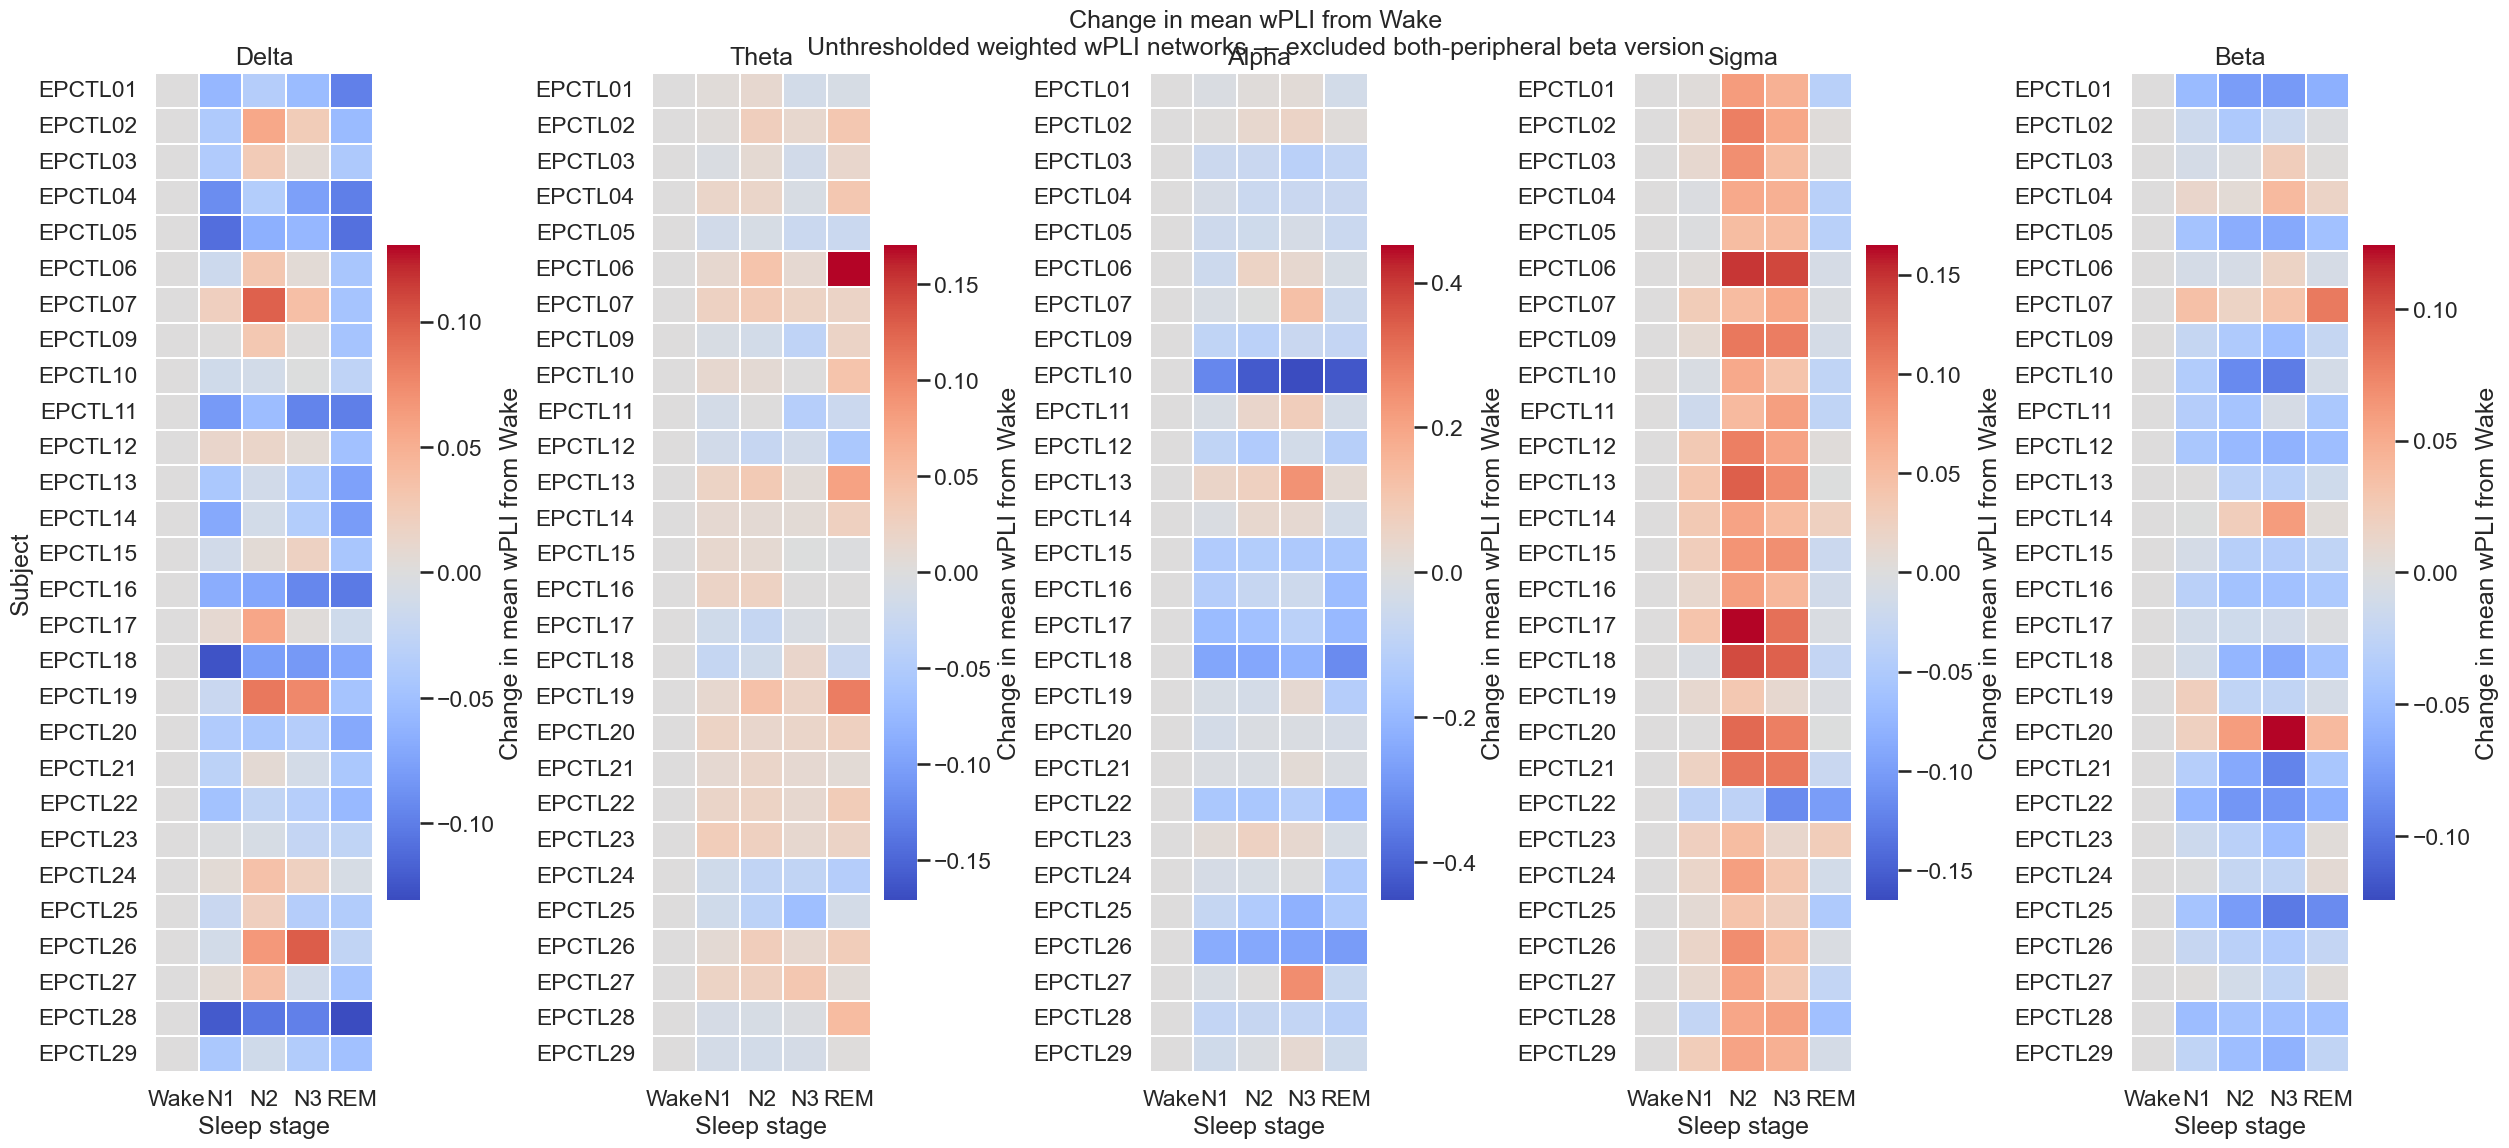

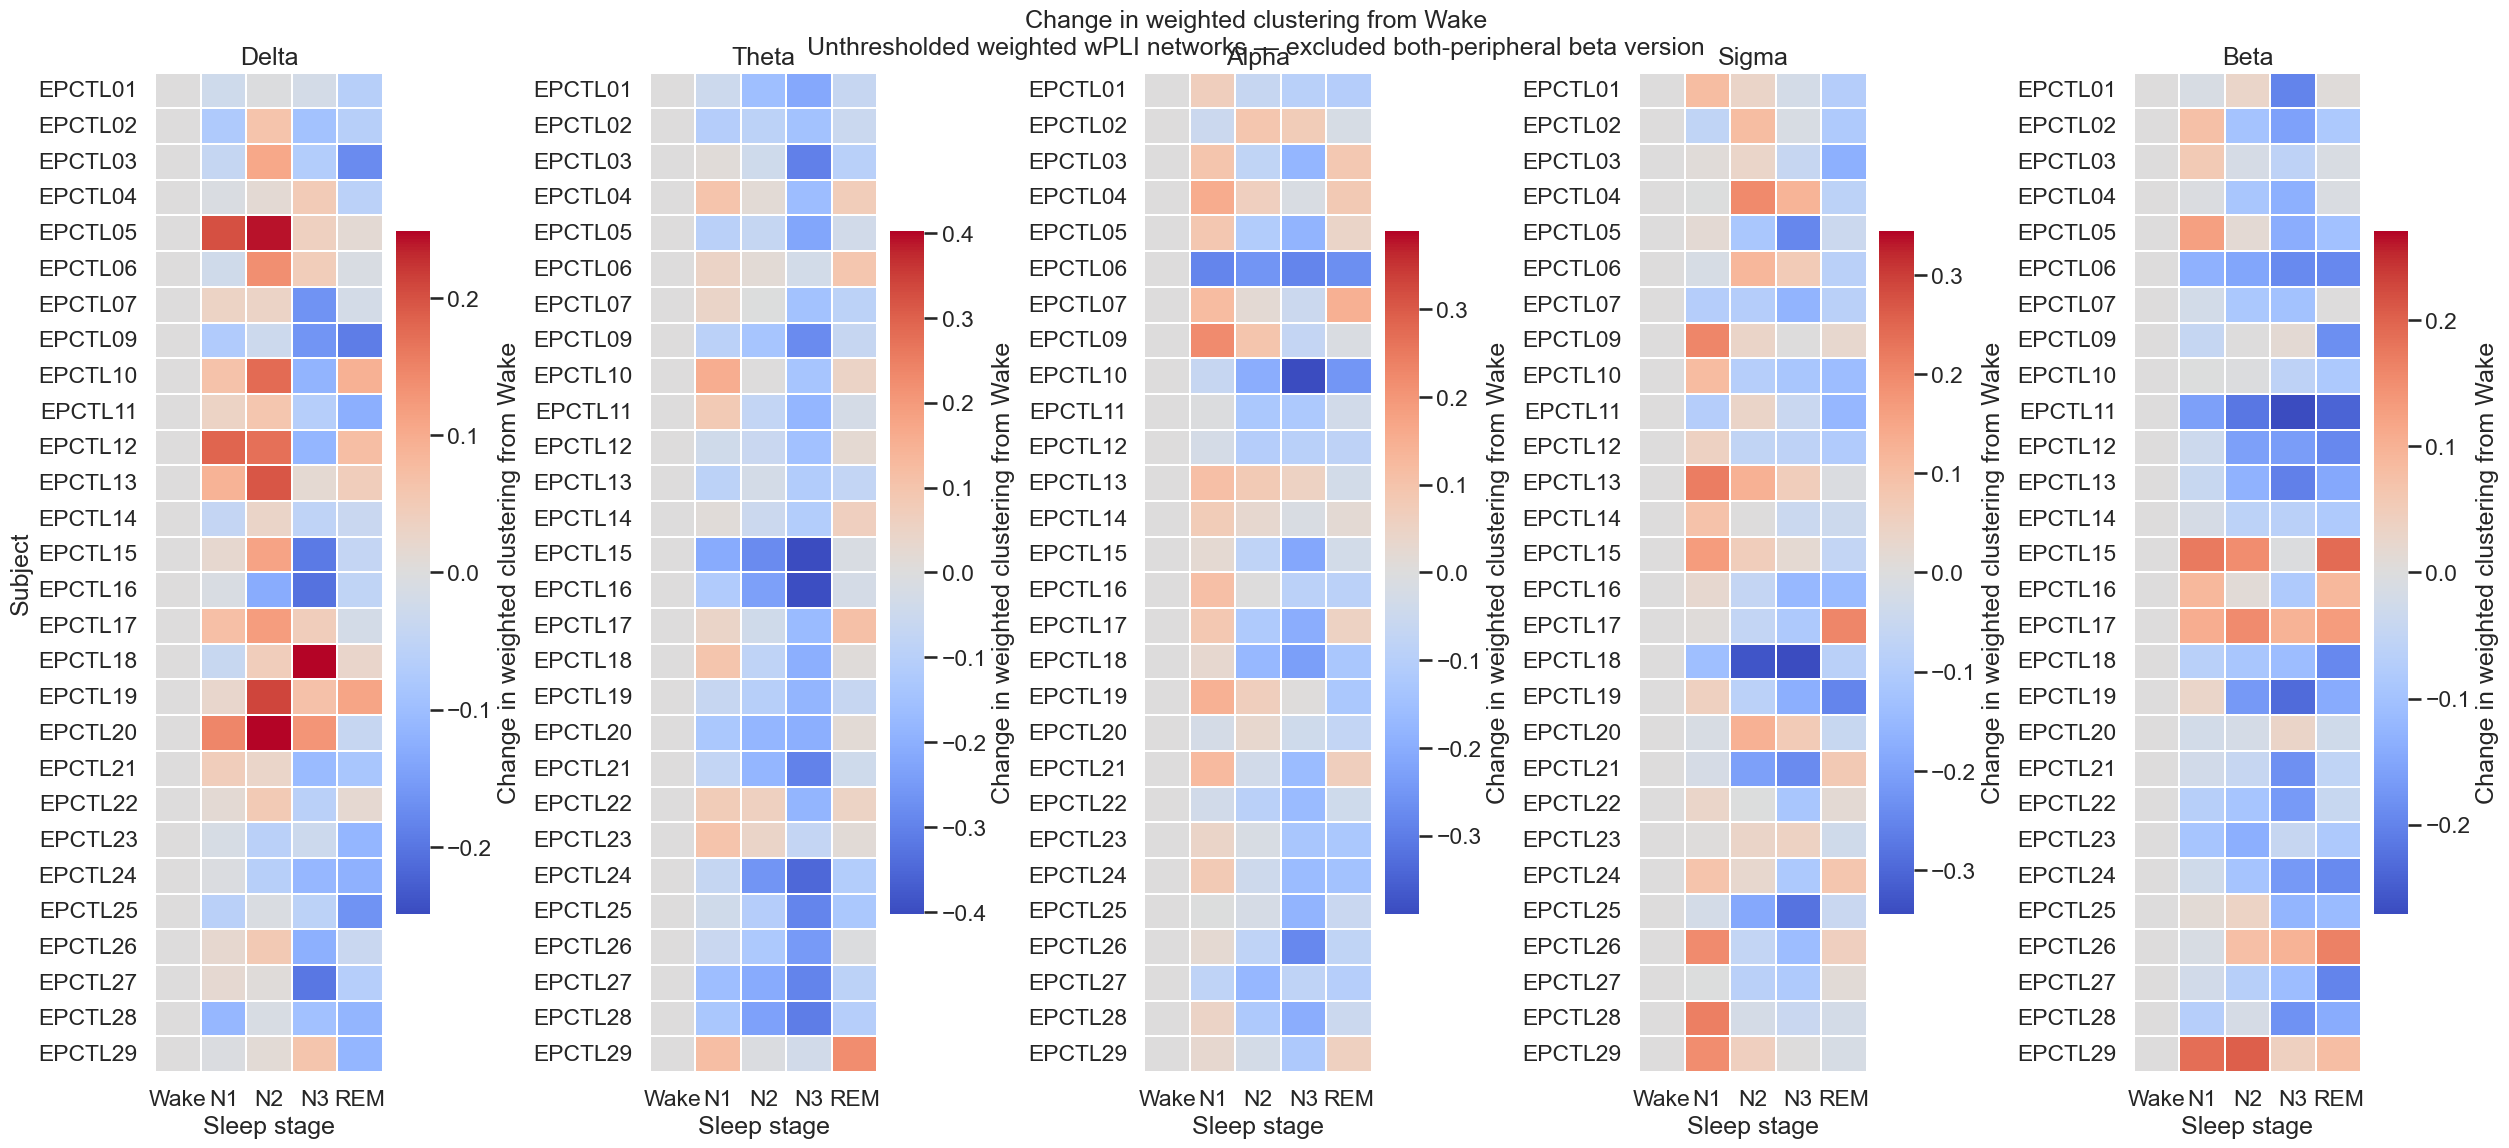

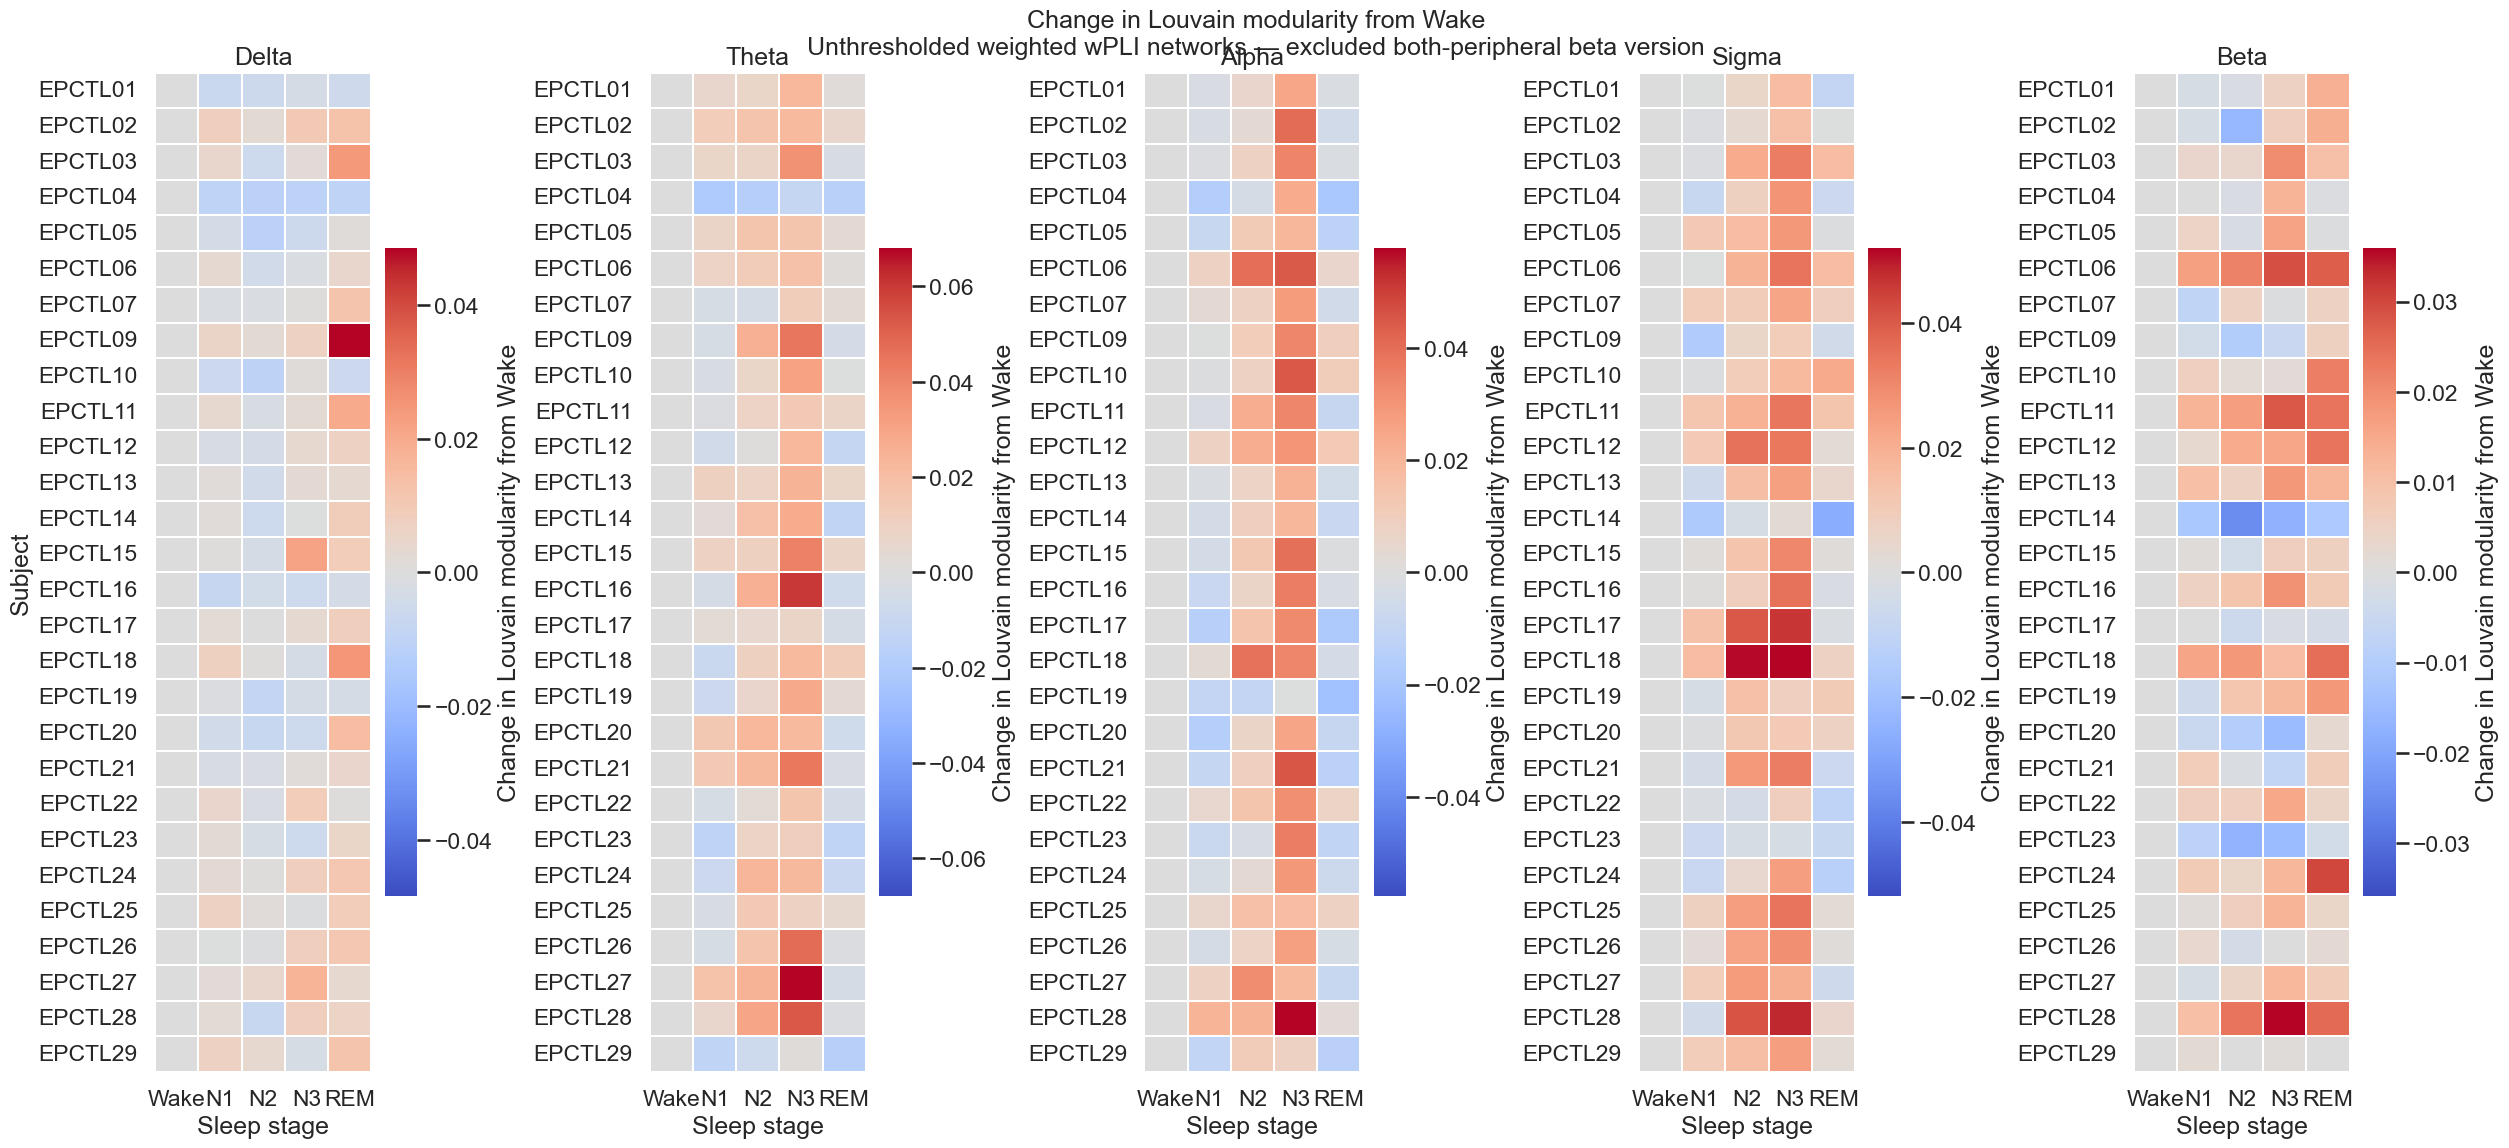

In [17]:
SUBJECT_ORDER = sorted(metrics_excluded["subject_id"].unique())
#metrics_to_plot = metrics_excluded.copy()
print(SUBJECT_ORDER)
print(f"Number of subjects: {len(SUBJECT_ORDER)}")

CHANGE_METRICS = {
    "mean_wpli": "Change in mean wPLI from Wake",
    "mean_weighted_clustering":
        "Change in weighted clustering from Wake",
    "modularity_louvain":
        "Change in Louvain modularity from Wake",
}

for metric_name, metric_label in CHANGE_METRICS.items():

    fig, axes = plt.subplots(
        1,
        len(BAND_ORDER),
        figsize=(25, 11),
        constrained_layout=True,
    )

    for ax, band in zip(axes, BAND_ORDER):

        band_data = metrics_df.loc[
            metrics_df["band"] == band
        ].copy()

        matrix = (
            band_data
            .pivot(
                index="subject_id",
                columns="stage",
                values=metric_name,
            )
            .reindex(
                index=SUBJECT_ORDER,
                columns=STAGE_ORDER,
            )
        )

        wake_values = matrix["Wake"]

        change_from_wake = matrix.subtract(
            wake_values,
            axis=0,
        )

        largest_absolute_change = np.nanmax(
            np.abs(change_from_wake.to_numpy())
        )

        sns.heatmap(
            change_from_wake,
            ax=ax,
            cmap="coolwarm",
            center=0,
            vmin=-largest_absolute_change,
            vmax=largest_absolute_change,
            linewidths=0.25,
            linecolor="white",
            cbar=True,
            cbar_kws={"label": metric_label},
        )

        ax.set_title(band.capitalize())
        ax.set_xlabel("Sleep stage")
        ax.set_ylabel("Subject" if band == BAND_ORDER[0] else "")

    fig.suptitle(
        f"{metric_label}\n"
        "Unthresholded weighted wPLI networks — excluded both-peripheral beta version",
        fontsize=18,
        y=1.03,
    )

    plt.show()

**Overall heatmap checks**

The figures show expected features:

- There is substantial between-subject variability, rather than every person showing the same artificial-looking pattern.
- Within a band, some stage trends recur across many participants.
- Wake is exactly neutral/grey.
- The excluded-beta pattern remains structured; it does not become random after removing the both-peripheral edges.

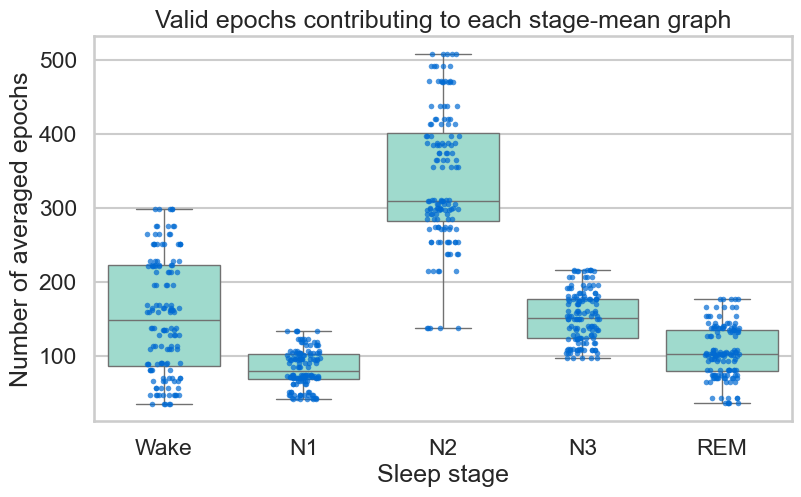

In [18]:
sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=metrics_excluded,
    x="stage",
    y="n_epochs_averaged",
    order=STAGE_ORDER,
    color="#95e4d2",
    showfliers=False,
)

sns.stripplot(
    data=metrics_excluded,
    x="stage",
    y="n_epochs_averaged",
    order=STAGE_ORDER,
    color="#016ad2",
    alpha=0.70,
    jitter=0.12,
    size=4,
)

plt.title("Valid epochs contributing to each stage-mean graph")
plt.xlabel("Sleep stage")
plt.ylabel("Number of averaged epochs")
plt.show()

Plot above shows that: N2 has the most available epochs and N1/REM have fewer. This is normal, but it's a precision limitation for those stage means

| Scientific question                                   | Current descriptive answer                                                                                                                                                                                               | Metric              |
| ----------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ | ------------------- |
| Does overall connectivity change across sleep stages? | Apparently yes, in a frequency-specific way. Sigma connectivity/integration is highest in N2/N3; beta connectivity is lower in NREM than Wake; alpha tends to decline after Wake; delta/theta effects are more variable. | Mean wPLI           |
| Does local network organization change?               | Apparently yes. Weighted clustering tends to decrease in N3 in theta, alpha, sigma, and beta, although individual differences are substantial.                                                                           | Weighted clustering |
| Does community structure change?                      | Apparently yes. Alpha and sigma modularity appear higher in N2/N3, especially N3; theta also shows an N3 increase; beta modularity may increase later in NREM.                                                           | Louvain modularity  |

 Formal repeated-measures statistical testing is required to determine which effects are reliable.

In [19]:
#SAVE EXCLUDED METRICS

METRICS_OUTPUT_DIR = Path("../graphs_output/stage_mean_wpli_graphs_exclude_both_beta_peripheral")
METRICS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

csv_path = (
    METRICS_OUTPUT_DIR
    / "static_metrics.csv"
)

pickle_path = (
    METRICS_OUTPUT_DIR
    / "static_metrics.pkl"
)

metrics_excluded.to_csv(csv_path, index=False)
metrics_excluded.to_pickle(pickle_path)

print("Saved CSV:", csv_path.resolve())
print("Saved pickle:", pickle_path.resolve())

print("\nBeta mode saved:")
print(metrics_excluded["beta_edge_mode"].unique())

print("\nRows saved:", len(metrics_excluded))

Saved CSV: C:\Users\itxas\OneDrive\Escritorio\NEURO_COSAS\My_project\graphs_output\stage_mean_wpli_graphs_exclude_both_beta_peripheral\static_metrics.csv
Saved pickle: C:\Users\itxas\OneDrive\Escritorio\NEURO_COSAS\My_project\graphs_output\stage_mean_wpli_graphs_exclude_both_beta_peripheral\static_metrics.pkl

Beta mode saved:
<StringArray>
['exclude_both_peripheral']
Length: 1, dtype: str

Rows saved: 700
